In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_raw = pd.read_csv('sri_lanka_irrigation_dataset.csv') 
print(f"Shape: {dataset_raw.shape} → {dataset_raw.shape[0]} records, {dataset_raw.shape[1]} features") 
pd.set_option('display.max_columns', None) 
dataset_raw.head()

Shape: (10000, 28) → 10000 records, 28 features


,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm,Gross_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,13.2,3.77,0.70,0.0,NaN
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,0.0,3.87,0.90,0.0,NaN
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,0.0,2.79,1.05,0.0,NaN
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,0.0,3.09,0.75,0.0,NaN
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,62.4,4.43,1.05,2.8,3.1


# We drop these columns because they are not necessary to predict the Net Irrigation Requirement (mm).

In [3]:
df_raw = dataset_raw.drop(["Gross_Irrigation_Requirement_mm", "Previous_Irrigation_mm"], axis=1)

In [4]:
df_raw

,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70,0.0
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90,0.0
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05,0.0
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75,0.0
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2498,Nuwara Eliya,Wet,Maha,Chili,Late-season,30,Clay,6.94,30.48,1.01,1.02,26.3,22.8,24.6,83.3,189.4,6.3,8.6,Furrow/Surface,Rainfed,0.59,No,2.55,0.90,0.0
9996,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Initial,20,Sandy,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,Drip,Minor Tank,0.59,No,4.84,1.05,38.6
9997,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Development,30,Sandy,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,Drip,Minor Tank,0.59,No,5.27,1.10,140.4
9998,2499,Kilinochchi,Dry,Yala,Paddy (Rice),Mid-season,40,Sandy,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,Drip,Minor Tank,0.59,No,5.37,1.20,119.2


# Here We inspect the dataset at this stage to detect "dirty" (inconsistent/corrupted) entries and identify any null (missing) values across all columns.

In [5]:
# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print(f"Wrong data types and dirty entries have been corrected.\n")

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
Field_Cycle_ID,int64,0,0.000000,2500,"[0, 1, 2]"
District,object,0,0.000000,25,"['Kalutara', 'Monaragala', 'Galle']"
Climate_Zone,object,0,0.000000,3,"['Wet', 'Intermediate', 'Dry']"
Season,object,0,0.000000,2,"['Maha', 'Yala']"
Crop_Type,object,0,0.000000,6,"['Big Onion', 'Paddy (Rice)', 'Tomato']"
Crop_Growth_Stage,object,0,0.000000,4,"['Initial', 'Development', 'Mid-season']"
Stage_Duration_days,int64,0,0.000000,11,"[15, 25, 35]"
Soil_Type,object,0,0.000000,4,"['Sandy Loam', 'Sandy', 'Loamy']"
Soil_pH,float64,0,0.000000,350,"[5.95, 5.77, 5.9]"
Soil_Moisture_pct,float64,0,0.000000,2867,"[15.2, 18.5, 18.9]"


Wrong data types and dirty entries have been corrected.



# The 'District' column is removed for two main reasons.

## 1.The specific environmental factors influenced by geography—such as climate, soil type, and rainfall—are already captured as precise, individual features. This makes the regional label redundant.

## 2. 'District' is a categorical variable with 25 unique values. Encoding it would introduce 25 new features, unnecessarily increasing dataset dimensionality and model complexity."

In [6]:
df_raw = df_raw.drop(["District"], axis=1, errors='ignore')

# I am doing this step bacuse to make sure the feature crops Coefficient (Kc) has the informations of  the featueres Crop_Type and Crop_Growth_Stage

In [7]:
# Create a pivot table showing the average, min, and max Kc values 
# broken down by each crop type and its specific growth stage
kc_profile = dataset_raw.groupby(['Crop_Type', 'Crop_Growth_Stage'])['Crop_Coefficient_Kc'].agg(
    Mean_Kc='mean',
    Min_Kc='min',
    Max_Kc='max',
    Record_Count='count'
).reset_index()

# Sort logically to keep crop lifecycle stages cohesive
print("--- Crop Coefficient (Kc) Breakdown by Growth Stage ---")
print(kc_profile.to_string(index=False))

--- Crop Coefficient (Kc) Breakdown by Growth Stage ---
   Crop_Type Crop_Growth_Stage  Mean_Kc  Min_Kc  Max_Kc  Record_Count
   Big Onion       Development     0.90    0.90    0.90           428
   Big Onion           Initial     0.70    0.70    0.70           428
   Big Onion       Late-season     0.75    0.75    0.75           428
   Big Onion        Mid-season     1.05    1.05    1.05           428
       Chili       Development     0.85    0.85    0.85           400
       Chili           Initial     0.60    0.60    0.60           400
       Chili       Late-season     0.90    0.90    0.90           400
       Chili        Mid-season     1.05    1.05    1.05           400
  Green Gram       Development     0.75    0.75    0.75           435
  Green Gram           Initial     0.40    0.40    0.40           435
  Green Gram       Late-season     0.40    0.40    0.40           435
  Green Gram        Mid-season     1.05    1.05    1.05           435
       Maize       Development    

In [8]:
df=df_raw.copy()

# Removing the Duplicate by rows and columns

In [9]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")

--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 10000 rows, 25 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 10000 rows, 25 features



# Analyze the Target Variable: Net_Irrigation_Requirement_mm

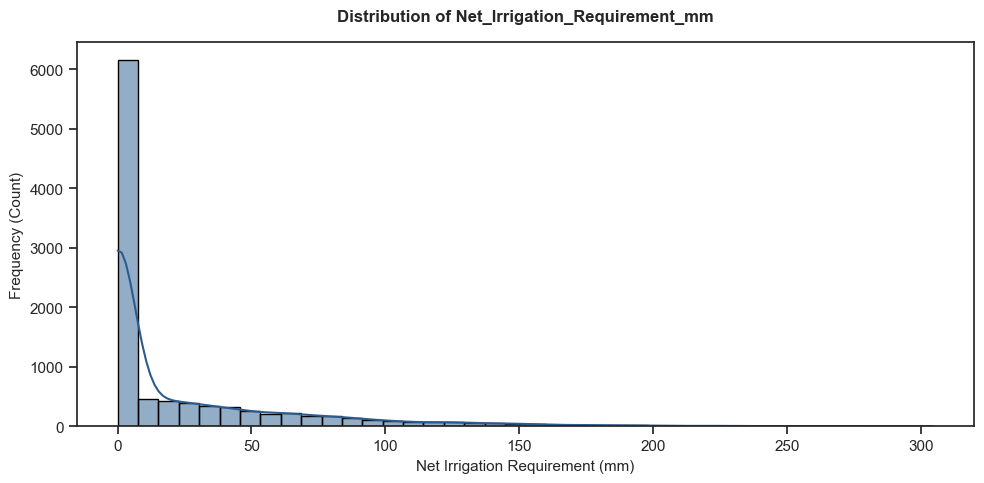

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting window style
plt.figure(figsize=(10, 5))
sns.set_theme(style="ticks")

# Plot the target variable distribution
sns.histplot(
    data=df, 
    x='Net_Irrigation_Requirement_mm', 
    bins=40, 
    color="#2b5c8f", 
    edgecolor="black", 
    kde=True
)

# Label the chart layout cleanly
plt.title("Distribution of Net_Irrigation_Requirement_mm", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Net Irrigation Requirement (mm)", fontsize=11)
plt.ylabel("Frequency (Count)", fontsize=11)

# Render the plot
plt.tight_layout()
plt.show()

### The histogram reveals that Net_Irrigation_Requirement_mm is heavily zero-inflated with a highly skewed right tail. Because standard regression algorithms struggle with this mixture of exact zeros and continuous positive values, we will implement a -- Hurdle Model -- architecture to optimize predictive performance.

# Splitting the Input featues and Target featute

In [11]:
X = df.drop(columns=['Net_Irrigation_Requirement_mm'])
y = df['Net_Irrigation_Requirement_mm']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (10000, 24)
Target vector  y: (10000,)


# Splitting the dataset based on group

In [12]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=df['Field_Cycle_ID']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nTrain Target Mean: {y_train.mean():.2f}")
print(f"Test Target Mean : {y_test.mean():.2f}")

Training Set : 8000 records
Testing Set  : 2000 records

Train Target Mean: 22.48
Test Target Mean : 23.65


In [13]:
print(X_train.shape)
X_train.head()

(8000, 24)


,Field_Cycle_ID,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc
0,0,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,3.77,0.70
1,0,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,3.87,0.90
2,0,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,2.79,1.05
3,0,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,3.09,0.75
4,1,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,4.43,1.05


# Making each list for the categorical features and numerical feature

In [14]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"\nQualitative  columns ({len(qual)}): {qual}")

Quantitative columns (16): ['Field_Cycle_ID', 'Stage_Duration_days', 'Soil_pH', 'Soil_Moisture_pct', 'Organic_Carbon_pct', 'Electrical_Conductivity_dSm', 'Tmax_C', 'Tmin_C', 'Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc']

Qualitative  columns (8): ['Climate_Zone', 'Season', 'Crop_Type', 'Crop_Growth_Stage', 'Soil_Type', 'Irrigation_Type', 'Water_Source', 'Mulching_Used']


In [15]:
quan

['Field_Cycle_ID',
 'Stage_Duration_days',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Organic_Carbon_pct',
 'Electrical_Conductivity_dSm',
 'Tmax_C',
 'Tmin_C',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc']

In [16]:
qual

['Climate_Zone',
 'Season',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Soil_Type',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used']

# Here we create a descriptive table with statistical values to find the outliers

In [17]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,Field_Cycle_ID,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Reference_ET0_mm_day,Crop_Coefficient_Kc
Mean,1244.8525,25.758125,5.762817,18.175491,1.013572,0.573488,30.775237,22.6777,26.726175,77.288875,129.563762,6.917075,9.49515,1.01285,4.210171,0.830894
Median,1234.5,25.0,5.75,17.35,0.98,0.54,30.5,22.8,26.6,78.7,102.15,6.9,9.2,0.82,4.19,0.85
Mode,0,20,5.75,12.6,0.68,0.05,30.7,23.2,26.3,79.2,0.0,6.3,8.2,0.1,3.92,1.05
Q1:25%,624.75,20.0,5.33,12.04,0.69,0.37,28.8,21.9,25.6,72.6,47.6,6.1,7.2,0.48,3.64,0.6
Q2:50%,1234.5,25.0,5.75,17.35,0.98,0.54,30.5,22.8,26.6,78.7,102.15,6.9,9.2,0.82,4.19,0.85
Q3:75%,1864.25,30.0,6.18,24.48,1.3,0.75,32.6,23.8,27.9,82.7,182.325,7.7,11.5,1.3825,4.8,1.05
Q4:100%,2499.0,60.0,7.9,36.75,2.69,1.84,38.7,27.6,31.8,96.8,920.4,10.7,22.3,4.99,6.63,1.2
IQR,1239.5,10.0,0.85,12.44,0.61,0.38,3.8,1.9,2.3,10.1,134.725,1.6,4.3,0.9025,1.16,0.45
1.5rule,1859.25,15.0,1.275,18.66,0.915,0.57,5.7,2.85,3.45,15.15,202.0875,2.4,6.45,1.35375,1.74,0.675
Lesser,-1234.5,5.0,4.055,-6.62,-0.225,-0.2,23.1,19.05,22.15,57.45,-154.4875,3.7,0.75,-0.87375,1.9,-0.075


# Box plots to visualize the outliers

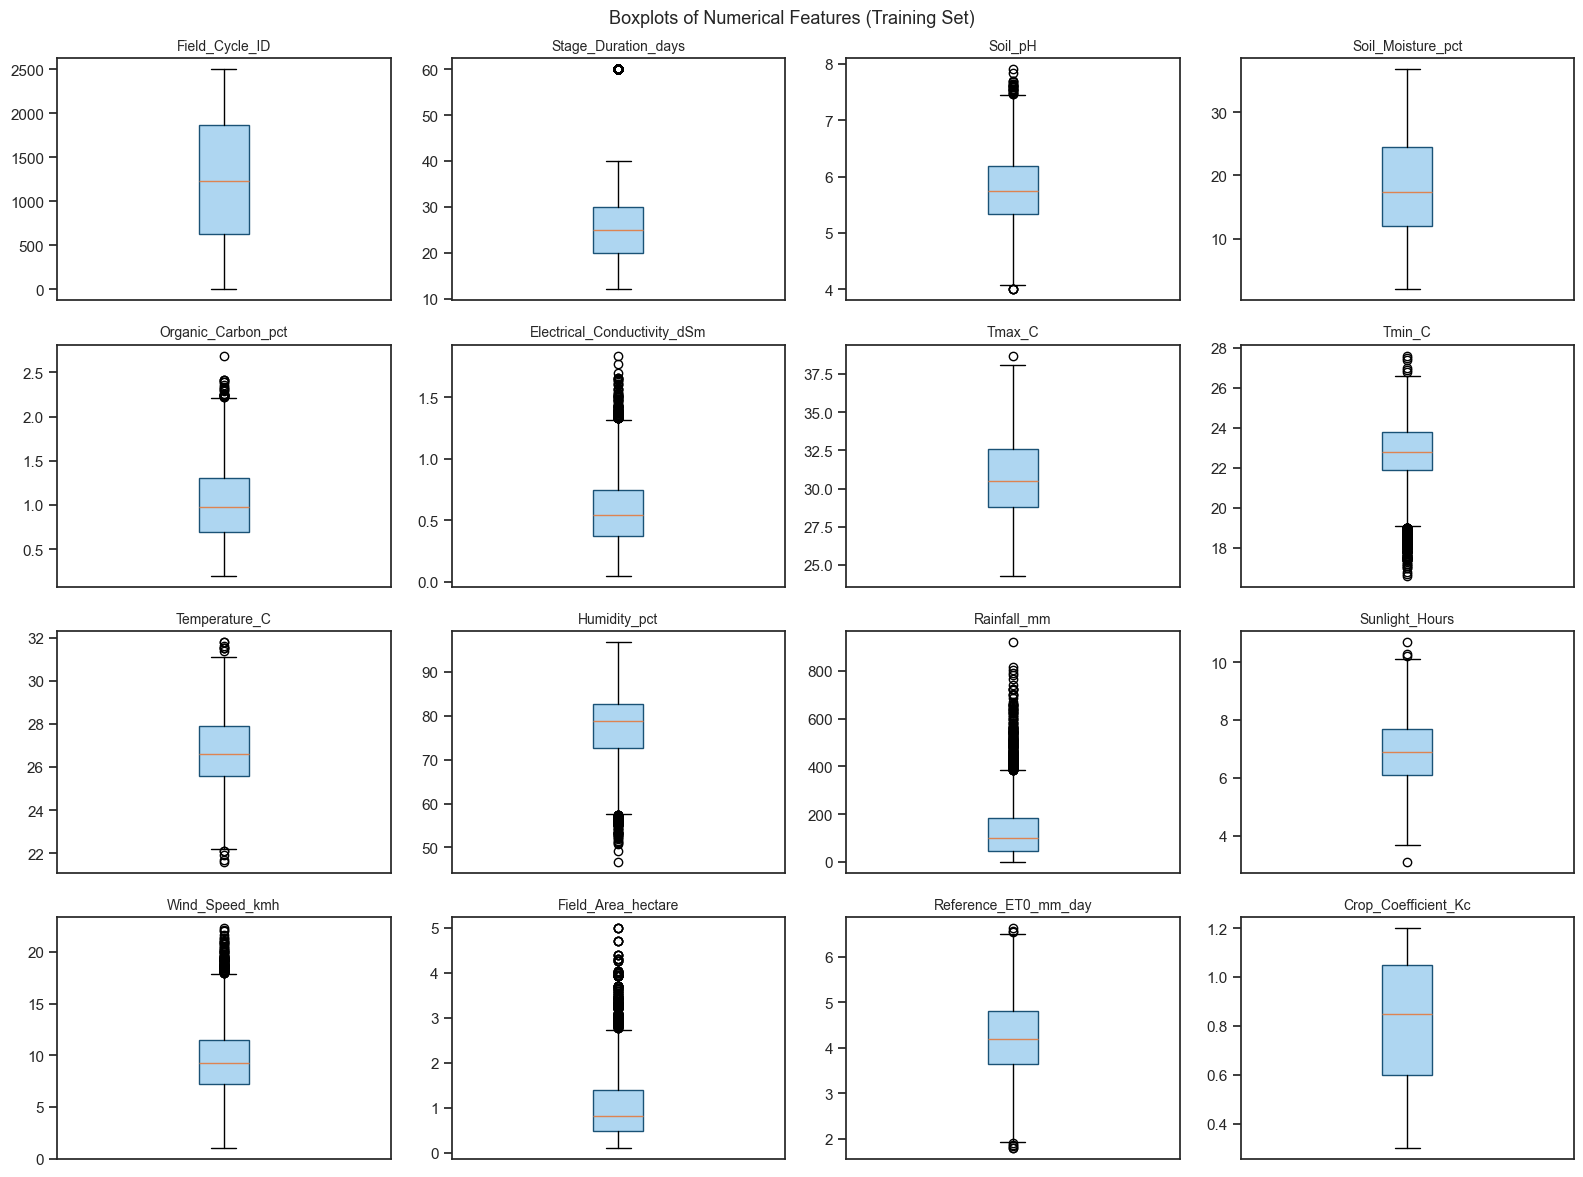

In [18]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [20]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,Soil_pH,4,0.05%,4.055,[4.0]
1,Tmin_C,240,3.00%,19.050,[16.6 to 19.0]
2,Temperature_C,5,0.06%,22.150,[21.6 to 22.1]
3,Humidity_pct,83,1.04%,57.450,[46.7 to 57.4]
4,Sunlight_Hours,1,0.01%,3.700,[3.1]
5,Reference_ET0_mm_day,5,0.06%,1.900,[1.79 to 1.9]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,Stage_Duration_days,306,3.82%,45.00000,[60]
1,Soil_pH,23,0.29%,7.45500,[7.46 to 7.9]
2,Organic_Carbon_pct,23,0.29%,2.21500,[2.22 to 2.69]
3,Electrical_Conductivity_dSm,106,1.32%,1.32000,[1.33 to 1.84]
4,Tmax_C,1,0.01%,38.30000,[38.7]
5,Tmin_C,6,0.07%,26.65000,[26.8 to 27.6]
6,Temperature_C,7,0.09%,31.35000,[31.4 to 31.8]
7,Rainfall_mm,290,3.62%,384.41250,[384.7 to 920.4]
8,Sunlight_Hours,3,0.04%,10.10000,[10.2 to 10.7]
9,Wind_Speed_kmh,105,1.31%,17.95000,[18.0 to 22.3]


### We have outliers in our dataset, but we will not remove them. These extreme values accurately represent real-world climate variations and severe weather conditions that are entirely plausible in a real-time scenario.

In [21]:
# Check skewness for all numerical features
skewness = X_train[quan].skew().sort_values(ascending=False)
print("Skewness of Numerical Features:\n", skewness)

Skewness of Numerical Features:
 Rainfall_mm                    1.521708
Field_Area_hectare             1.437137
Stage_Duration_days            1.306003
Electrical_Conductivity_dSm    0.576827
Wind_Speed_kmh                 0.524010
Soil_Moisture_pct              0.438857
Organic_Carbon_pct             0.382661
Tmax_C                         0.279310
Soil_pH                        0.142257
Sunlight_Hours                 0.128731
Temperature_C                  0.111458
Reference_ET0_mm_day           0.014535
Field_Cycle_ID                 0.011566
Crop_Coefficient_Kc           -0.423666
Humidity_pct                  -0.631520
Tmin_C                        -0.649567
dtype: float64


### Our dataset contains significant skewness in several features, and we have deliberately retained outliers to capture true environmental variations. To avoid misleading the model and creating biased patterns, we are using tree-based models. These algorithms rely on value-splitting rather than distance metrics, making them completely immune to feature skewness.

# Visualizing the distributions of numarical features

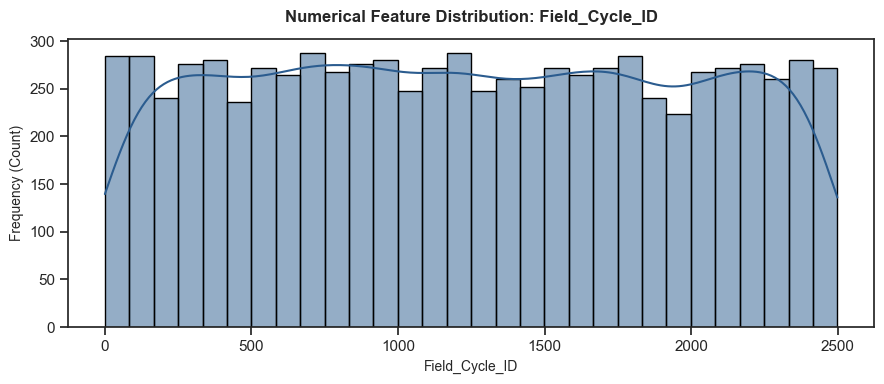

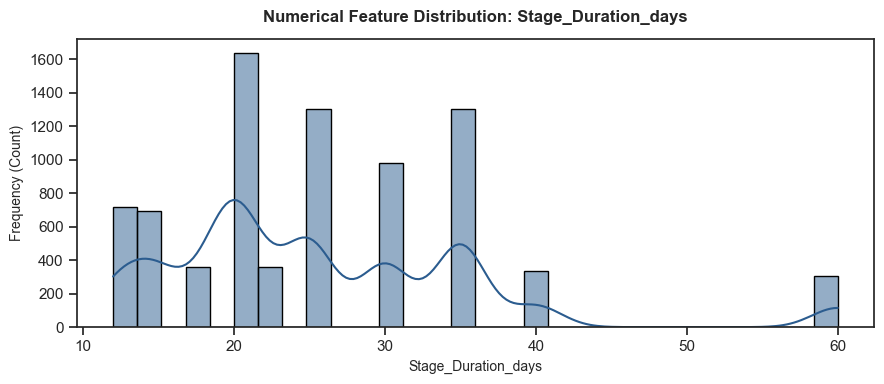

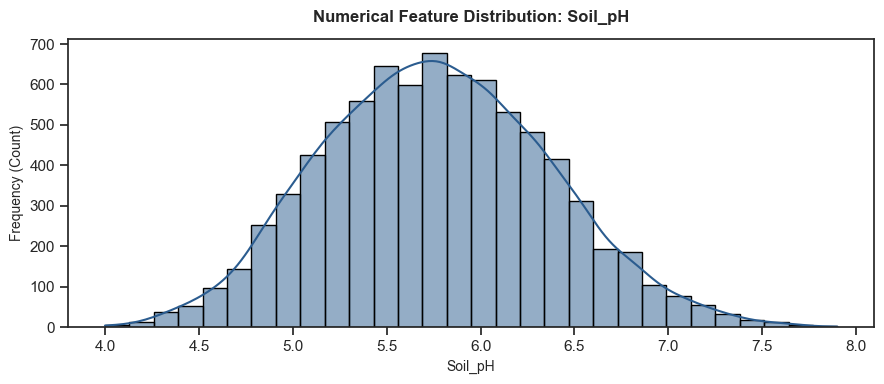

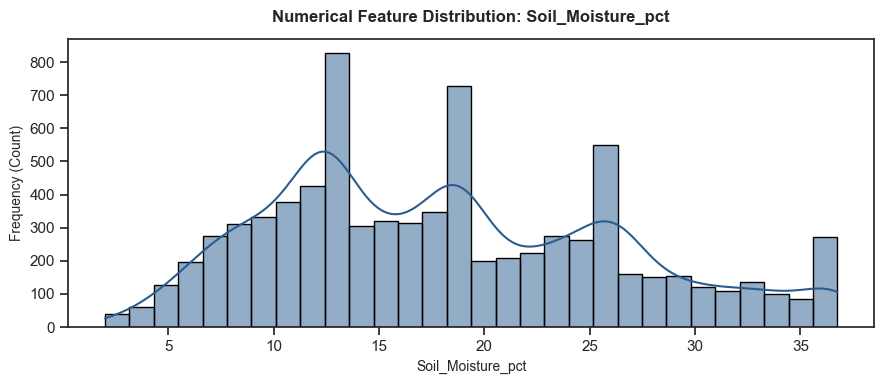

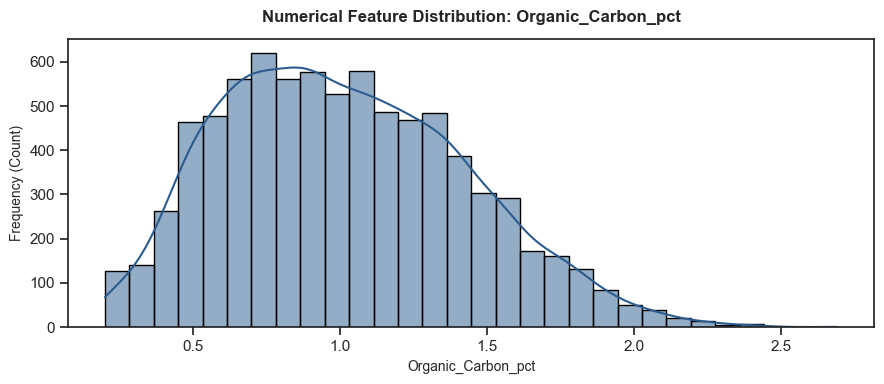

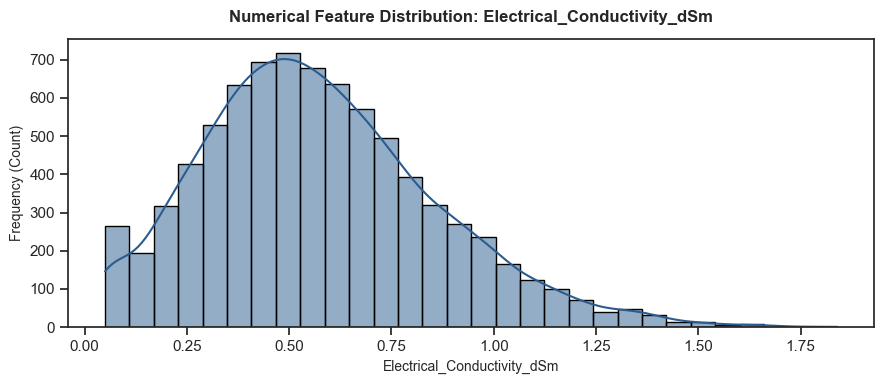

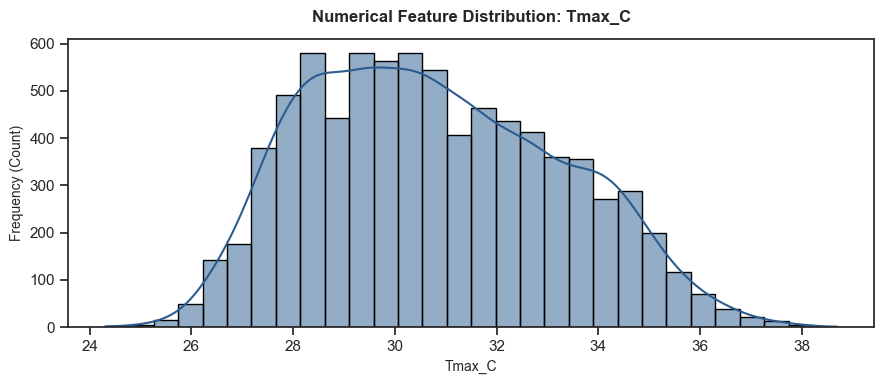

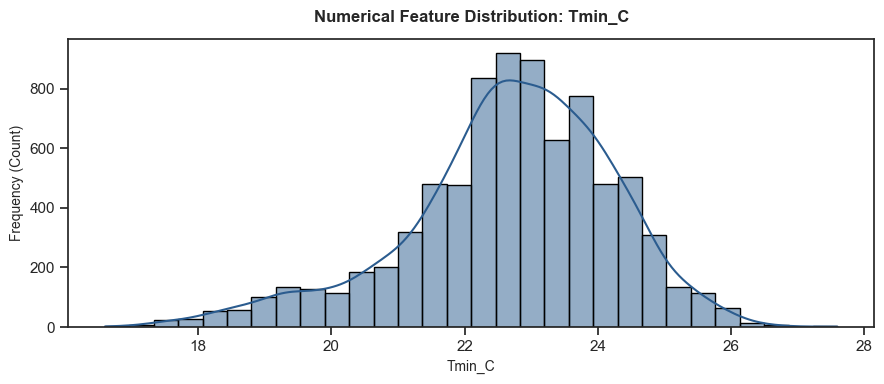

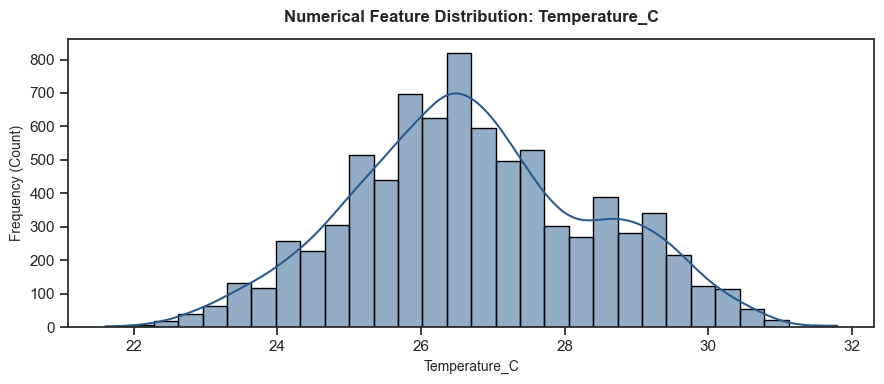

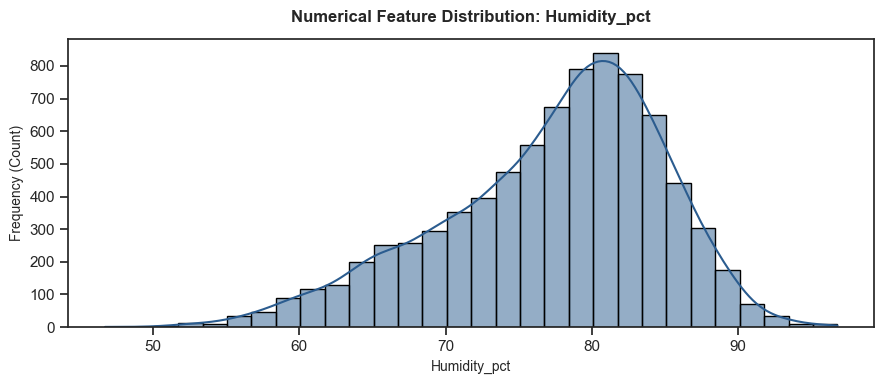

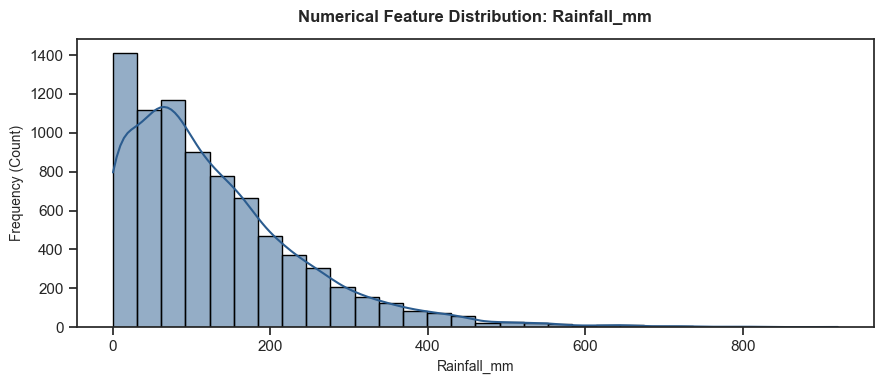

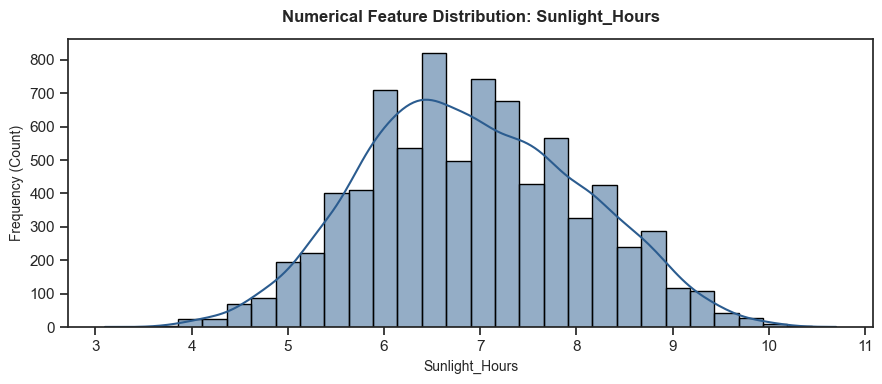

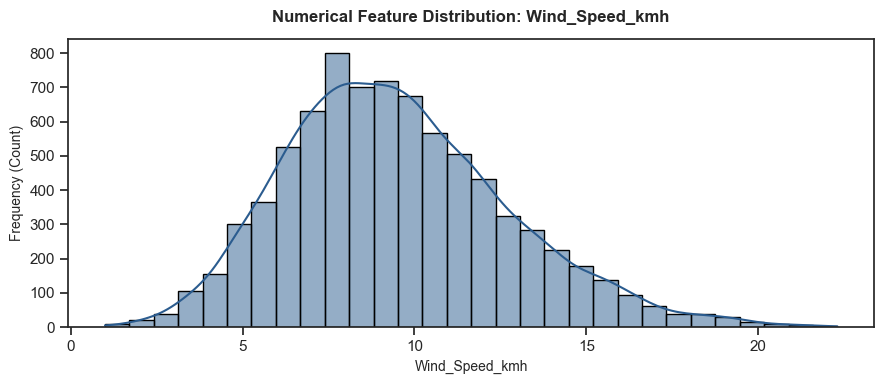

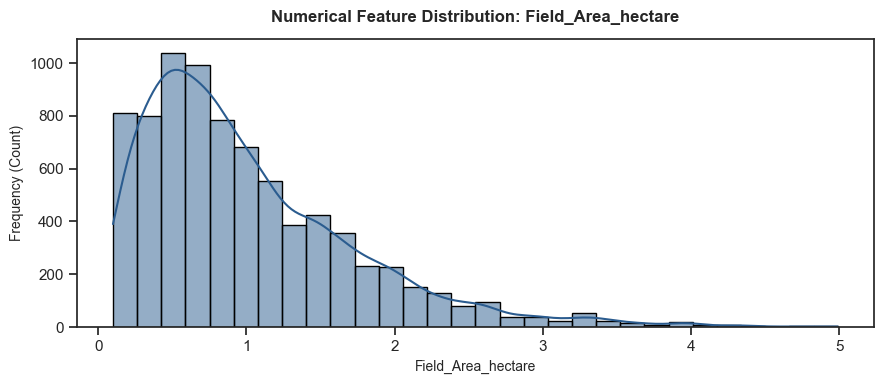

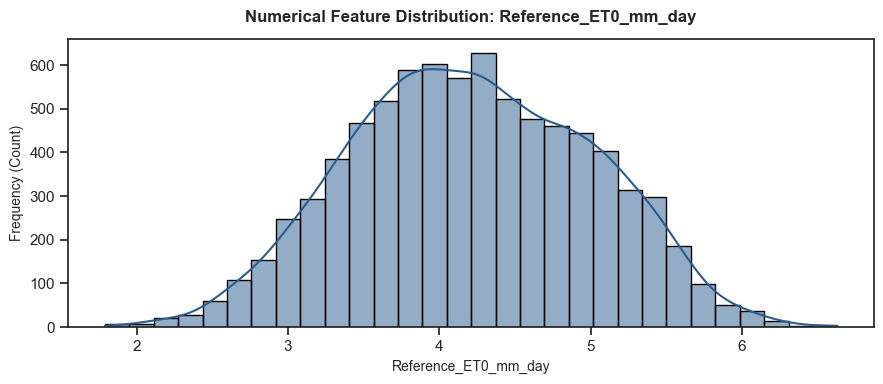

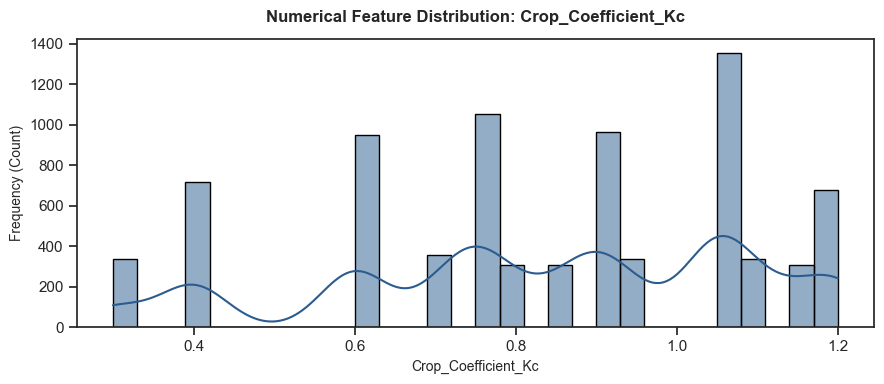

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual looping architecture for quantitative columns
for col in quan:
    plt.figure(figsize=(9, 4))
    sns.set_theme(style="ticks")
    
    # Plot histogram with a KDE line to see the underlying shape
    sns.histplot(
        data=X_train, 
        x=col, 
        bins=30, 
        color="#2b5c8f", 
        edgecolor="black", 
        kde=True
    )
    
    plt.title(f"Numerical Feature Distribution: {col}", fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Frequency (Count)", fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Analize the categorical features

In [23]:
# Print frequency distribution for categorical columns
for col in qual:
    print(f"=== Distribution for {col} ===")
    
    # Calculate counts and percentages
    counts = X_train[col].value_counts()
    percentages = X_train[col].value_counts(normalize=True) * 100
    
    # Combine into a clean summary table
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary, "\n")

=== Distribution for Climate_Zone ===
              Count  Percentage (%)
Climate_Zone                       
Dry            3784            47.3
Wet            2920            36.5
Intermediate   1296            16.2 

=== Distribution for Season ===
        Count  Percentage (%)
Season                       
Maha     4120            51.5
Yala     3880            48.5 

=== Distribution for Crop_Type ===
              Count  Percentage (%)
Crop_Type                          
Green Gram     1432           17.90
Big Onion      1420           17.75
Paddy (Rice)   1352           16.90
Maize          1352           16.90
Chili          1224           15.30
Tomato         1220           15.25 

=== Distribution for Crop_Growth_Stage ===
                   Count  Percentage (%)
Crop_Growth_Stage                       
Initial             2000            25.0
Development         2000            25.0
Mid-season          2000            25.0
Late-season         2000            25.0 

=== Distri

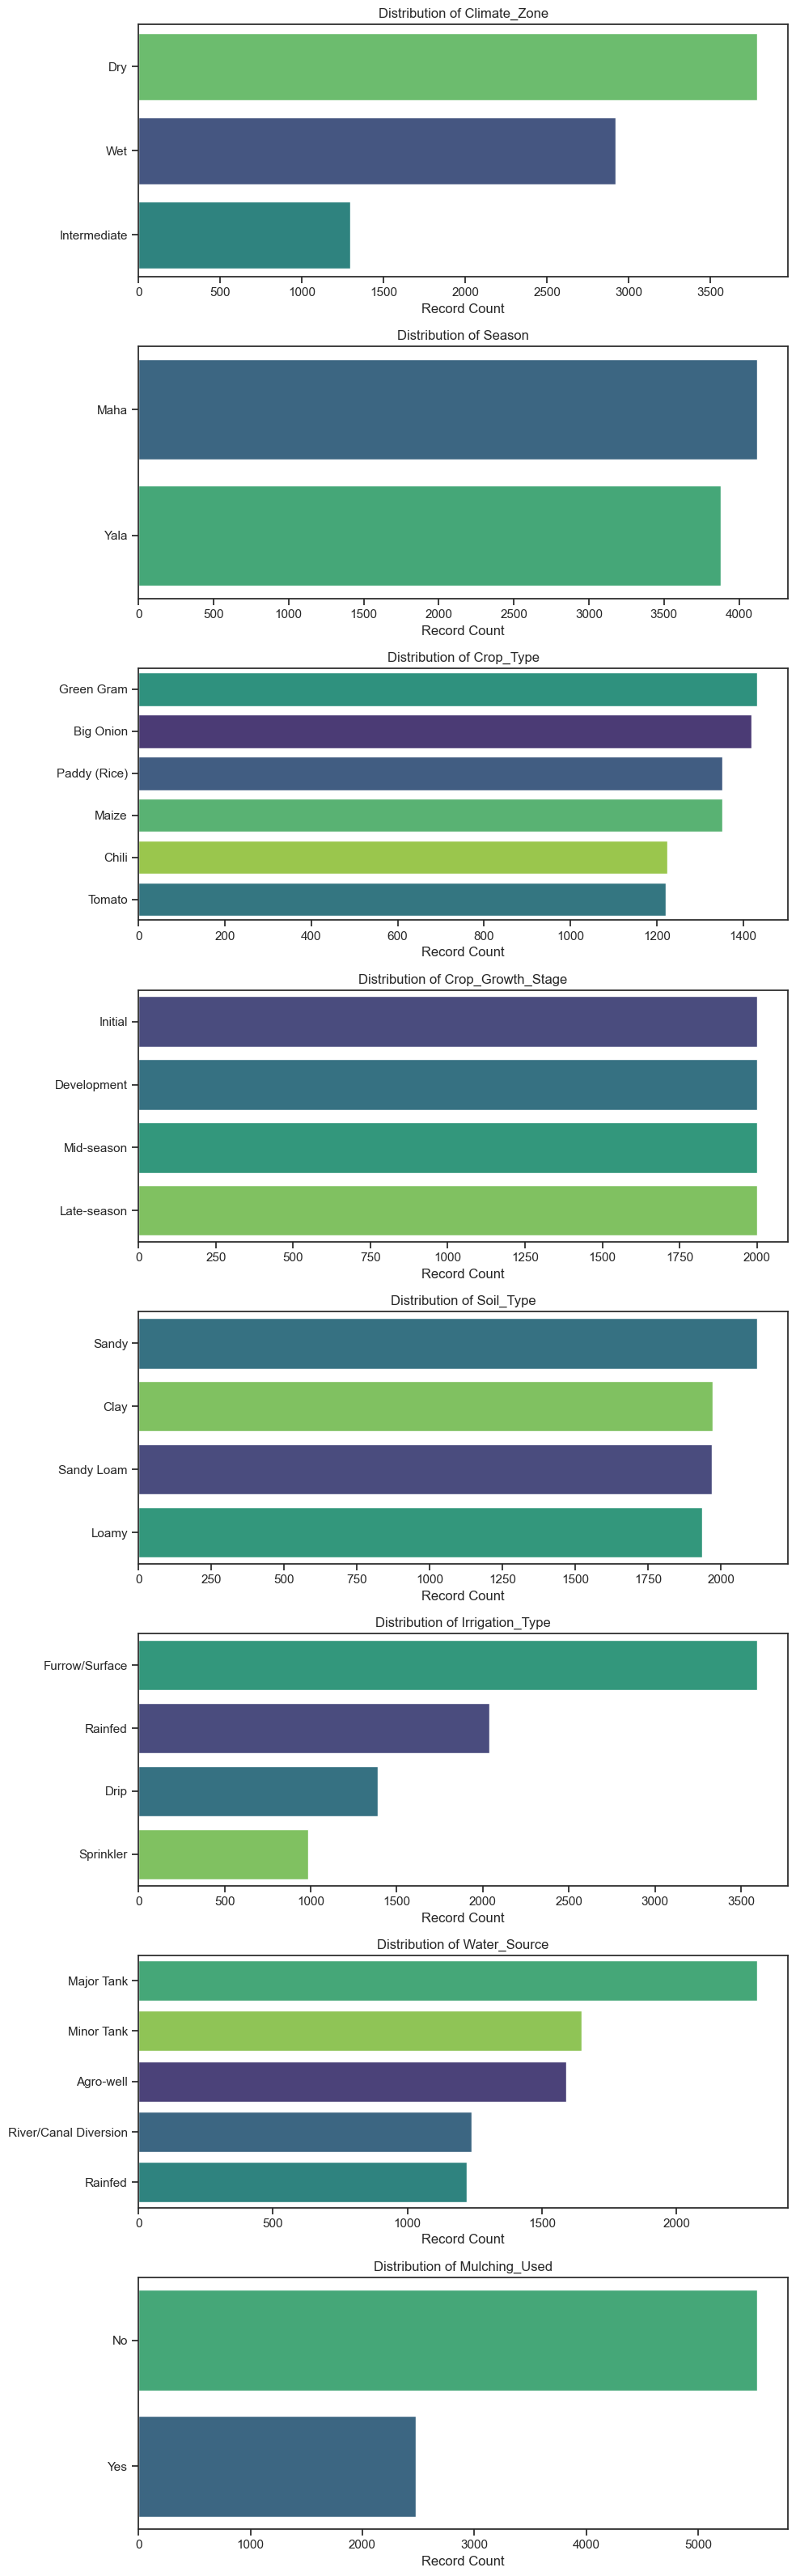

In [24]:
num_cols = len(qual)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

# If there is only 1 categorical column, convert axes to an array to prevent errors
if num_cols == 1:
    axes = [axes]

# Plot a countplot for each categorical feature
for i, col in enumerate(qual):
    # Added hue=col and legend=False to fix the deprecation warning
    sns.countplot(
        data=X_train, 
        y=col, 
        ax=axes[i], 
        order=X_train[col].value_counts().index, 
        palette="viridis",
        hue=col,
        legend=False
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Record Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [25]:
X_train_clean=X_train.copy()
X_test_clean=X_test.copy()

# The Encoding (Categorical ----> Numarical)

In [26]:
from sklearn.preprocessing import OneHotEncoder

X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# here we find the categorical features as bianry and multiple class in X_train_encoded
#====================================================================================
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)})")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)})\n")
# ====================================================================================


# encoding our binary categorical features
# ====================================================================================
if binary_cols:
    for col in binary_cols:
        # Cast to standard string arrays and read the unique elements present in the training set
        train_categories = X_train_encoded[col].astype(str).unique()
        
        # Build an explicit, clean 0/1 integer index mapping dictionary layout
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        
        # Apply mapping across columns simultaneously via native vectorized math.
        # Unknown values in test split are safely caught using .fillna(0) to prevent rogue negative coordinates
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
# ====================================================================================


# Here we are encoding the multi class categorical columns
# ====================================================================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)
# ====================================================================================

=== Encoding Feature Categorization ===
🔹 Binary features mapped (2)
🔹 Multi-class features mapped (6)



# From here, we will build our Hurdle Model, combining Classification and Regression

## 1. Classification Model

### Preparing the Dataset for the Classification Model

In [27]:
X_train_clf= X_train_encoded.copy()
y_train_clf = (y_train > 0).astype(int)

In [28]:
X_test_clf= X_test_encoded.copy()
y_test_clf = (y_test > 0).astype(int)

In [29]:
X_train_clf

,Field_Cycle_ID,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
0,0,0,15,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,0.92,0,3.77,0.70,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
1,0,0,25,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,0.92,0,3.87,0.90,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2,0,0,35,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,0.92,0,2.79,1.05,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,0,20,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,0.92,0,3.09,0.75,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
4,1,0,20,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,1.63,1,4.43,1.05,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,2496,0,30,5.34,12.60,0.37,0.60,28.1,23.4,25.8,78.5,129.0,4.3,5.1,0.99,1,3.02,0.90,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0
9996,2499,1,20,4.93,10.02,0.68,0.27,33.2,24.7,28.9,64.7,70.7,9.2,6.3,0.59,1,4.84,1.05,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
9997,2499,1,30,4.81,12.60,0.62,0.25,35.3,25.5,30.4,62.7,0.0,8.9,15.8,0.59,1,5.27,1.10,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
9998,2499,1,40,4.73,12.60,0.76,0.33,35.2,24.5,29.8,64.1,134.2,8.8,15.8,0.59,1,5.37,1.20,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0


In [30]:
y_train_clf.unique()

array([0, 1])

# Features Scalling

In [31]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_clf_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clf), 
    columns=X_train_clf.columns, 
    index=X_train_clf.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_clf_scaled = pd.DataFrame(
    scaler.transform(X_test_clf), 
    columns=X_test_clf.columns, 
    index=X_test_clf.index
)

# Checking the correlation between features to avoid the multicollinearity

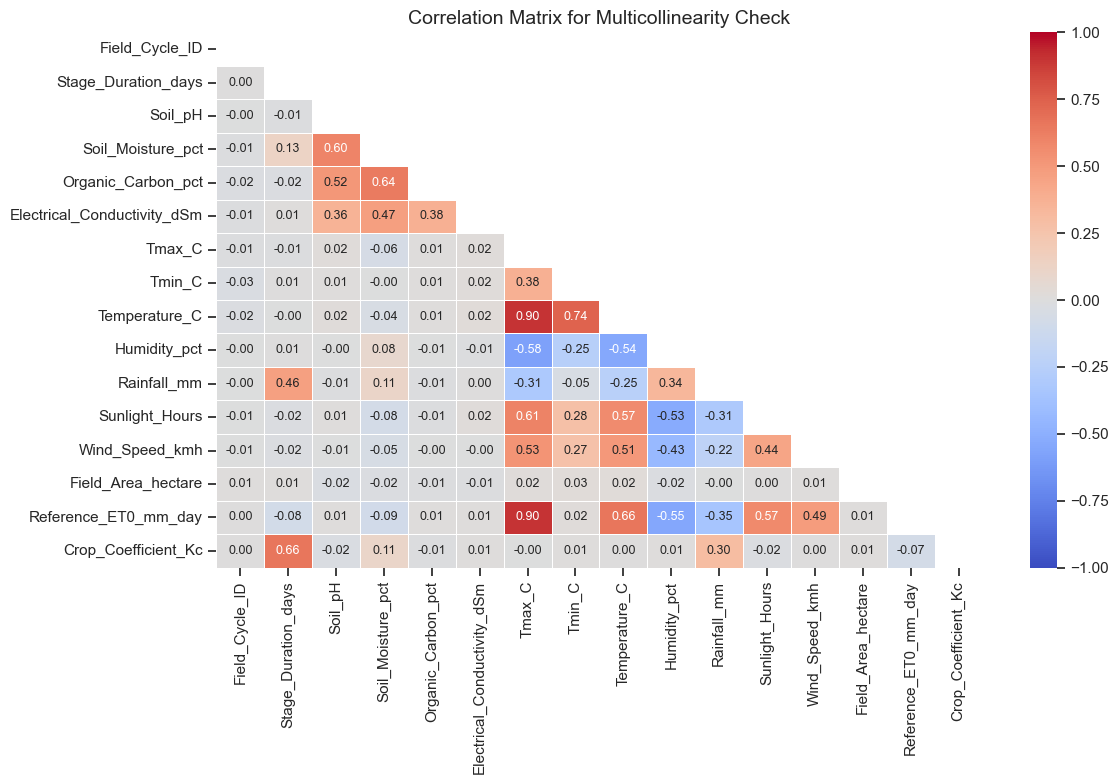


--- Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2258.097575
1                        Tmax_C  1206.443993
2                        Tmin_C   492.318343
3          Reference_ET0_mm_day    18.763827
4             Soil_Moisture_pct     2.338666
5           Stage_Duration_days     2.201417
6           Crop_Coefficient_Kc     1.822846
7                Sunlight_Hours     1.811463
8            Organic_Carbon_pct     1.809919
9                  Humidity_pct     1.771432
10                      Soil_pH     1.679471
11                  Rainfall_mm     1.575809
12               Wind_Speed_kmh     1.501711
13  Electrical_Conductivity_dSm     1.322539
14           Field_Area_hectare     1.002791
15               Field_Cycle_ID     1.001262


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure we ONLY check multicollinearity on numerical features
# (Using encoded categorical variables will break VIF or cause infinite scores)
X_train_numerical = X_train_clf_scaled[quan]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_numerical.columns

# Calculate VIF score safely for each numerical feature
vif_data["VIF"] = [
    variance_inflation_factor(X_train_numerical.values, i) 
    for i in range(X_train_numerical.shape[1])
]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

--- Top 12 Most Important Features (Classification) ---
                 Feature  Importance
0            Rainfall_mm    0.339467
1                 Tmax_C    0.061058
2   Reference_ET0_mm_day    0.057781
3    Crop_Coefficient_Kc    0.053690
4          Temperature_C    0.053374
5           Humidity_pct    0.049730
6    Stage_Duration_days    0.036864
7         Sunlight_Hours    0.033673
8         Wind_Speed_kmh    0.024320
9       Climate_Zone_Wet    0.024290
10                Season    0.024285
11                Tmin_C    0.022887


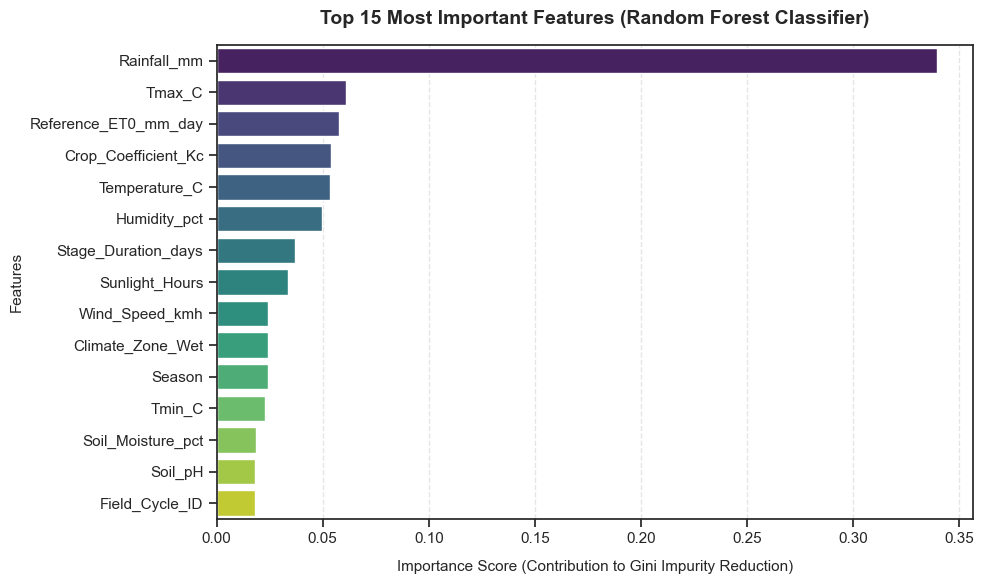

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# FIX 1: Import the Classifier instead of the Regressor
from sklearn.ensemble import RandomForestClassifier

# 1. INITIALIZE AND TRAIN THE MODEL FOR CLASSIFICATION
# FIX 2: Swap the model to Classifier and train on your binary target (y_train_clf)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_clf_scaled, y_train_clf)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_clf_scaled.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 12 Most Important Features (Classification) ---")
print(importance_df.head(12))

# =====================================================================
# 3. PLOT THE TOP 15 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select the top 15 rows to match your plotting variable
top_importance = importance_df.head(15)

# Set a wider, cleaner figure size optimized for 15 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using the top 15 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# FIX 3: Updated titles to reflect Classification (Gini Impurity Contribution)
plt.title('Top 15 Most Important Features (Random Forest Classifier)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Gini Impurity Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# We droped the featues (Tempreature_C and Tmax_C) to avoid Multicollinearity based on Correlation matrix, VIF Score and Featute Importance ranking

In [34]:
X_train_clf_final = X_train_clf_scaled.drop(columns=['Temperature_C', 'Tmin_C'])

# 2. Mirror the exact same step on the testing data
X_test_clf_final = X_test_clf_scaled.drop(columns=['Temperature_C', 'Tmin_C'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_clf_final.shape} | Test: {X_test_clf_final.shape}")

Cleaned Data Shapes -> Train: (8000, 42) | Test: (2000, 42)


In [35]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold

# Extract the aligned group variable safely (pointing to your cleaned training index)
groups_aligned = df.loc[X_train_clf_final.index, 'Field_Cycle_ID']

# 1. Initialize a fast tree estimator for classification and group-based CV strategy
# FIX 2: Swap the model to ExtraTreesClassifier
fast_classifier = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
cv_strategy     = GroupKFold(n_splits=5) 

# 2. Fit RFECV using Classification Scoring (ROC AUC handles imbalanced zero days beautifully)
# FIX 3: Swap scoring from 'neg_mean_absolute_error' to 'roc_auc' (or 'accuracy')
rfecv_clf = RFECV(
    estimator=fast_classifier, 
    step=1, # Setting step=1 ensures precise dropping for feature optimization
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1
)

# FIX 4: Pass your classification features (X_train_clf_final) and binary target (y_train_clf)
rfecv_clf.fit(X_train_clf_final, y_train_clf, groups=groups_aligned)

# 3. Extract optimal indices
optimal_n_clf      = rfecv_clf.n_features_
selected_feats_clf = X_train_clf_final.columns[rfecv_clf.support_].tolist()

print("--- RFE Classification Selection Summary ---")
print(f"Original number of features : {X_train_clf_final.shape[1]}")
print(f"Number of selected features  : {optimal_n_clf}")

print("\n✅ SELECTED CLASSIFICATION FEATURES:")
print(selected_feats_clf)


--- RFE Classification Selection Summary ---
Original number of features : 42
Number of selected features  : 9

✅ SELECTED CLASSIFICATION FEATURES:
['Season', 'Stage_Duration_days', 'Tmax_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Climate_Zone_Wet']


# Here, we create a new dataframe that contains only the selected features

In [36]:
X_train_clf_pre = X_train_clf_final[selected_feats_clf]
X_test_clf_pre  = X_test_clf_final[selected_feats_clf]  

# Multi-Model Performance Benchmarking using only selected features

In [37]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# Extract aligned group IDs matching the exact index of your X_train_clf_pre matrix
train_groups = df.loc[X_train_clf_pre.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Binary Hurdle Decisions (0 = Dry, 1 = Water)
CLASSIFICATION_MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN Classifier":      KNeighborsClassifier(n_neighbors=5),
    "SVM Classifier (RBF)": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42, n_estimators=100),
}

# FIX 1: Generate the binary target for testing (Implicit deep copy, completely leak-free)
y_test_clf = (y_test > 0).astype(int)

results_clf = []
for name, model in CLASSIFICATION_MODELS.items():
    
    # 3. Step A: Cross-Validation using ROC AUC
    cv_scores = cross_val_score(
        model, 
        X_train_clf_pre, 
        y_train_clf, 
        cv=cv5, 
        groups=train_groups, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    mean_cv_auc = cv_scores.mean()
    
    # 4. Step B: Train ONCE on the training matrix to predict on the test set
    model.fit(X_train_clf_pre, y_train_clf)
    
    # Predict hard classes (0 or 1) and continuous probabilities
    y_pred_class = model.predict(X_test_clf_pre)
    y_pred_proba = model.predict_proba(X_test_clf_pre)[:, 1]
    
    # 5. FIX 2: Calculate classification performance metrics against y_test_clf (NOT y_test)
    test_auc      = roc_auc_score(y_test_clf, y_pred_proba)
    test_accuracy = accuracy_score(y_test_clf, y_pred_class)
    test_f1       = f1_score(y_test_clf, y_pred_class)
    
    # 6. Collect all classification metrics for this model row
    results_clf.append({
        "Model": name,
        "CV ROC AUC (Train)": mean_cv_auc, 
        "Test ROC AUC":       test_auc,
        "Test Accuracy":      test_accuracy,
        "Test F1-Score":      test_f1
    })

# 7. Turn into a DataFrame and rank by the HIGHEST Cross-Validation ROC AUC score
benchmark_table_clf = pd.DataFrame(results_clf)
benchmark_table_clf = benchmark_table_clf.sort_values(by="CV ROC AUC (Train)", ascending=False).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_clf["CV ROC AUC (Train)"] = benchmark_table_clf["CV ROC AUC (Train)"].map(lambda x: f"{x:.4f}")
benchmark_table_clf["Test ROC AUC"]       = benchmark_table_clf["Test ROC AUC"].map(lambda x: f"{x:.4f}")
benchmark_table_clf["Test Accuracy"]      = benchmark_table_clf["Test Accuracy"].map(lambda x: f"{x*100:.2f}%" if not pd.isna(x) else x)
benchmark_table_clf["Test F1-Score"]      = benchmark_table_clf["Test F1-Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 1 CLASSIFICATION MODEL BENCHMARK TABLE (Ranked by Highest CV ROC AUC)")
print("="*95)
display(benchmark_table_clf)


📊 STAGE 1 CLASSIFICATION MODEL BENCHMARK TABLE (Ranked by Highest CV ROC AUC)


,Model,CV ROC AUC (Train),Test ROC AUC,Test Accuracy,Test F1-Score
0,Gradient Boosting,0.9946,0.9954,95.85%,0.9515
1,SVM Classifier (RBF),0.9940,0.9940,95.95%,0.9531
2,Random Forest,0.9930,0.9946,96.00%,0.9533
3,Logistic Regression,0.9897,0.9893,94.00%,0.9310
4,KNN Classifier,0.9640,0.9724,91.85%,0.9035
5,Decision Tree,0.9407,0.9490,94.90%,0.9416


### The Random Forest Classifier was selected because it achieved the top Test Accuracy (96.00%) and Test F1-Score (0.9533), generalized perfectly to unseen fields without overfitting

In [38]:
import pandas as pd
# FIX 1: Import Classifier instead of Regressor
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and train the proper classification engine
# FIX 2: Use RandomForestClassifier and point to your specific classification datasets
clf_production_engine = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_production_engine.fit(X_train_clf_pre, y_train_clf)

# 2. Extract and match scores using your classification feature columns
rankings_clf = pd.Series(clf_production_engine.feature_importances_, index=X_train_clf_pre.columns)
limited_features_clf = rankings_clf.nlargest(5).index.tolist()

print("--- True Random Forest Classifier Rankings ---")
print(rankings_clf.sort_values(ascending=False))

print(f"\n✅ Use these 5 features for your cost-effective Stage 1 deployment pipeline:\n{limited_features_clf}")

--- True Random Forest Classifier Rankings ---
Rainfall_mm             0.465155
Crop_Coefficient_Kc     0.114978
Reference_ET0_mm_day    0.090205
Tmax_C                  0.089165
Stage_Duration_days     0.082465
Humidity_pct            0.060737
Sunlight_Hours          0.040274
Season                  0.029857
Climate_Zone_Wet        0.027164
dtype: float64

✅ Use these 5 features for your cost-effective Stage 1 deployment pipeline:
['Rainfall_mm', 'Crop_Coefficient_Kc', 'Reference_ET0_mm_day', 'Tmax_C', 'Stage_Duration_days']


# Here we are find the best parameters for our model

In [39]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import RandomForestClassifier

groups_clf = df.loc[X_train_clf_pre.index, 'Field_Cycle_ID']

param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}
cv = GroupKFold(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=30,          # Only evaluates 30 combinations
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

random_search.fit(
    X_train_clf_pre,
    y_train_clf,
    groups=groups_clf
)

best_rf_classifier = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=30. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
0.9931810555064466


🏆 FINAL TUNED STAGE 1 CLASSIFICATION MODEL REPORT
Final Model ROC AUC Score           : 0.9946
                  precision    recall  f1-score   support

     Dry Day (0)       0.96      0.97      0.96      1134
Watering Day (1)       0.96      0.94      0.95       866

        accuracy                           0.96      2000
       macro avg       0.96      0.96      0.96      2000
    weighted avg       0.96      0.96      0.96      2000



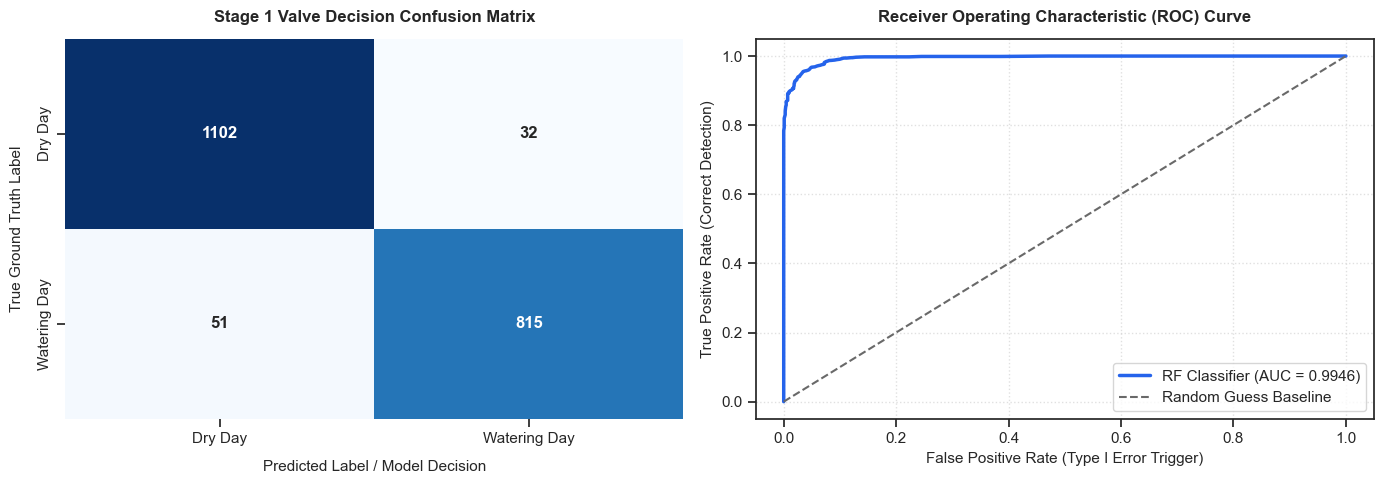

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Import Proper Classification Reporting Modules
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    ConfusionMatrixDisplay
)

# 1. Predict on your SELECTED classification test features
y_pred_class = best_rf_classifier.predict(X_test_clf_pre)
y_pred_proba = best_rf_classifier.predict_proba(X_test_clf_pre)[:, 1]

# 2. Calculate Final Performance Metrics on Unseen Classification Test Data
final_auc = roc_auc_score(y_test_clf, y_pred_proba)

print("🏆 FINAL TUNED STAGE 1 CLASSIFICATION MODEL REPORT")
print("=" * 65)
print(f"Final Model ROC AUC Score           : {final_auc:.4f}")
print("=" * 65)
# Generates complete Precision, Recall, and F1 breakdowns for both class 0 and class 1
print(classification_report(y_test_clf, y_pred_class, target_names=['Dry Day (0)', 'Watering Day (1)']))
print("=" * 65)

# 3. Structural Evaluation Graphics Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="ticks")

# Plot A: Confusion Matrix Heatmap (Reveals Valve Control Misclassifications)
cm = confusion_matrix(y_test_clf, y_pred_class)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0], 
    xticklabels=['Dry Day', 'Watering Day'], 
    yticklabels=['Dry Day', 'Watering Day'],
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_xlabel('Predicted Label / Model Decision', fontsize=11, labelpad=10)
axes[0].set_ylabel('True Ground Truth Label', fontsize=11, labelpad=10)
axes[0].set_title('Stage 1 Valve Decision Confusion Matrix', fontsize=12, fontweight='bold', pad=12)

# Plot B: ROC Curve (Evaluates General Classifier Separation Thresholds)
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2563EB', linewidth=2.5, label=f'RF Classifier (AUC = {final_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='dimgray', linestyle='--', linewidth=1.5, label='Random Guess Baseline')
axes[1].set_xlabel('False Positive Rate (Type I Error Trigger)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Correct Detection)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Regression Model for Predicting Irrigation Water Volume

### Preparing the Dataset for the Regression Model

In [42]:
# 1. Define the mask strictly based on active watering days (Ground truth > 0)
mask = y_train > 0

# 2. Filter your SELECTED training features and target matrices cleanly
# FIX: Using your clean, selected feature space instead of raw X_train
X_train_reg = X_train_encoded[mask].copy() 
y_train_reg = y_train[mask].copy()

# 3. Mirror the exact same step on the testing data to keep dimensions aligned
mask_test = y_test > 0
X_test_reg  = X_test_encoded[mask_test].copy()
y_test_reg  = y_test[mask_test].copy()

# --- Quick verification check ---
print("="*60)
print("🔒 STAGE 2 DATA ISOLATION COMPLETE (Active Watering Days Only)")
print("="*60)
print(f"Regression Training Matrix Shape : {X_train_reg.shape}")
print(f"Regression Testing Matrix Shape  : {X_test_reg.shape}")
print("="*60)

🔒 STAGE 2 DATA ISOLATION COMPLETE (Active Watering Days Only)
Regression Training Matrix Shape : (3432, 44)
Regression Testing Matrix Shape  : (866, 44)


In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Initialize a fresh StandardScaler instance exclusively for Stage 2 Regression
reg_scaler = StandardScaler()

# 2. FIT & TRANSFORM: Calculate mean/variance ONLY on active watering training rows
X_train_reg_scaled = pd.DataFrame(
    reg_scaler.fit_transform(X_train_reg), 
    columns=X_train_reg.columns, 
    index=X_train_reg.index
)

# 3. TRANSFORM ONLY: Mirror onto the regression test set (No Leakage)
X_test_reg_scaled = pd.DataFrame(
    reg_scaler.transform(X_test_reg), 
    columns=X_test_reg.columns, 
    index=X_test_reg.index
)

# --- Quick verification check ---
print("="*60)
print(f"Scaled Reg Train Dimensions : {X_train_reg_scaled.shape}")
print(f"Scaled Reg Test Dimensions  : {X_test_reg_scaled.shape}")
print("="*60)


Scaled Reg Train Dimensions : (3432, 44)
Scaled Reg Test Dimensions  : (866, 44)


In [47]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the baseline regressor (always predicts the mean of active watering days)
dummy_reg = DummyRegressor(strategy='mean')

# FIX: Fit strictly on the positive-only training rows
dummy_reg.fit(X_train_reg_scaled, y_train_reg)

# 2. Predict on the isolated regression test set
y_dummy_pred = dummy_reg.predict(X_test_reg_scaled)

# 3. Evaluate the benchmark against the positive test ground-truth (y_test_reg)
print("="*65)
print(f"Baseline MAE      : {mean_absolute_error(y_test_reg, y_dummy_pred):.2f} mm")
print(f"Baseline R² Score : {r2_score(y_test_reg, y_dummy_pred):.4f}")
print("="*65)
print("Any Stage 2 model you train MUST achieve a LOWER MAE and a HIGHER R² score than this.")
print("="*65)

Baseline MAE      : 36.58 mm
Baseline R² Score : -0.0022
Any Stage 2 model you train MUST achieve a LOWER MAE and a HIGHER R² score than this.


# Checking the correlation between features to avoid the multicollinearity

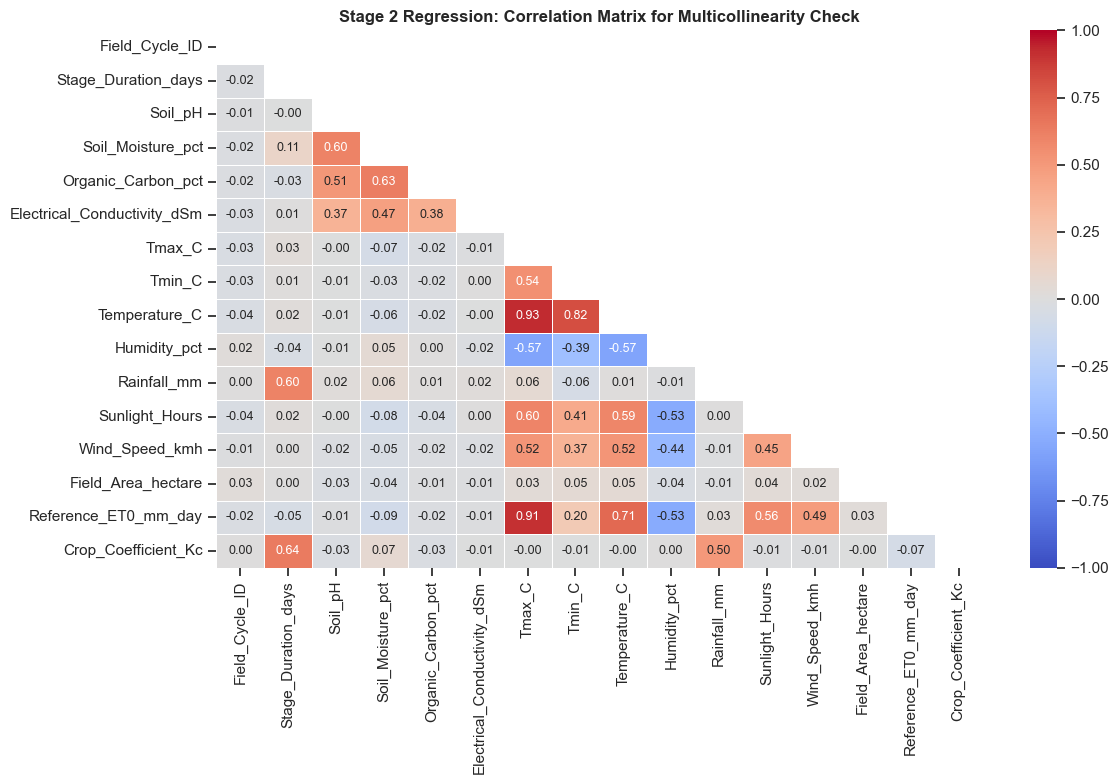


--- Stage 2 Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2460.335683
1                        Tmax_C  1180.056885
2                        Tmin_C   492.065565
3          Reference_ET0_mm_day    21.685572
4             Soil_Moisture_pct     2.278118
5           Stage_Duration_days     2.193628
6                Sunlight_Hours     1.857042
7            Organic_Carbon_pct     1.779823
8           Crop_Coefficient_Kc     1.775216
9                  Humidity_pct     1.721376
10                      Soil_pH     1.681708
11                  Rainfall_mm     1.681682
12               Wind_Speed_kmh     1.523215
13  Electrical_Conductivity_dSm     1.320064
14           Field_Area_hectare     1.006867
15               Field_Cycle_ID     1.004698


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. FIX: Intersect your quantitative feature list with active Stage 2 columns
# This protects against KeyError if features were dropped or altered upstream
quan_existing = [col for col in quan if col in X_train_reg_scaled.columns]
X_train_numerical_reg = X_train_reg_scaled[quan_existing]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical_reg.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Stage 2 Regression: Correlation Matrix for Multicollinearity Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data_reg = pd.DataFrame()
vif_data_reg["Feature"] = X_train_numerical_reg.columns

# Calculate VIF score safely for each active numerical feature in the regression space
vif_data_reg["VIF"] = [
    variance_inflation_factor(X_train_numerical_reg.values, i) 
    for i in range(X_train_numerical_reg.shape[1])
]

# Sort features by VIF score in descending order
vif_data_reg = vif_data_reg.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Stage 2 Variance Inflation Factor (VIF) Scores ---")
print(vif_data_reg)

--- Top 12 Most Important Features (Stage 2 Regression) ---
                 Feature  Importance
0    Stage_Duration_days    0.333179
1            Rainfall_mm    0.257837
2   Reference_ET0_mm_day    0.181252
3    Crop_Coefficient_Kc    0.104156
4                 Tmax_C    0.017908
5          Temperature_C    0.013964
6      Soil_Moisture_pct    0.012477
7           Humidity_pct    0.007499
8         Sunlight_Hours    0.006264
9         Wind_Speed_kmh    0.005831
10    Organic_Carbon_pct    0.005814
11        Field_Cycle_ID    0.005010


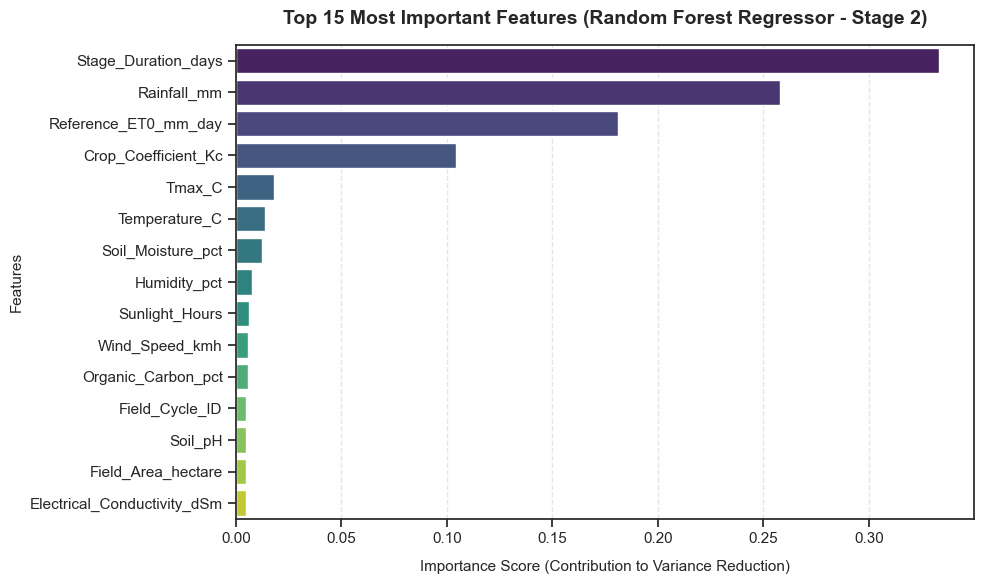

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. INITIALIZE AND TRAIN THE MODEL ON STAGE 2 REGRESSION DATA
# FIX: Swapped inputs to your positive-only, scaled regression variables
rf_regressor_stage2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor_stage2.fit(X_train_reg_scaled, y_train_reg)

# 2. EXTRACT SCORES AND PAIR THEM WITH REGRESSION COLUMN NAMES
# FIX: Updated column references to match X_train_reg_scaled columns
importance_df_reg = pd.DataFrame({
    'Feature': X_train_reg_scaled.columns,
    'Importance': rf_regressor_stage2.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 12 Most Important Features (Stage 2 Regression) ---")
print(importance_df_reg.head(12))

# =====================================================================
# 3. PLOT THE TOP 15 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select the top 15 rows to match your slice index down below
top_importance_reg = importance_df_reg.head(15)

# Set a wider, cleaner figure size optimized for 15 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using only the top 15 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance_reg, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# Add clean labels, a larger title, and clear gridlines for readability
plt.title('Top 15 Most Important Features (Random Forest Regressor - Stage 2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Variance Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# We droped the featues (Tempreature_C and Tmax_C) to avoid Multicollinearity based on Correlation matrix, VIF Score and Featute Importance ranking

In [50]:
X_train_reg_final = X_train_reg_scaled.drop(columns=['Temperature_C', 'Tmin_C'], errors='ignore')
X_test_reg_final  = X_test_reg_scaled.drop(columns=['Temperature_C', 'Tmin_C'], errors='ignore')

# Finding the best features using RFECV using GroupKFold

In [51]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold

# Extract the aligned group variable safely from the isolated regression index
# FIX 1: Point to your Stage 2 regression feature matrix index
groups_aligned_reg = df.loc[X_train_reg_final.index, 'Field_Cycle_ID']

# 1. Initialize a fast tree estimator and group-based CV strategy
fast_estimator_reg = ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1)
cv_strategy_reg    = GroupKFold(n_splits=5) 

# 2. Fit RFECV using Negative MAE Scoring
rfecv_reg = RFECV(
    estimator=fast_estimator_reg, 
    step=1, # Setting step=1 ensures highly precise feature pruning
    cv=cv_strategy_reg, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1
)

# Fit using the safely aligned groups array
# FIX 2: Pass your exact Stage 2 matrices (X_train_reg_final and y_train_reg)
rfecv_reg.fit(X_train_reg_final, y_train_reg, groups=groups_aligned_reg)

# 3. Extract optimal indices
optimal_n_reg      = rfecv_reg.n_features_
selected_feats_reg = X_train_reg_final.columns[rfecv_reg.support_].tolist()

print("--- RFE Stage 2 Regression Selection Summary ---")
print(f"Original number of features : {X_train_reg_final.shape[1]}")
print(f"Number of selected features  : {optimal_n_reg}")

print("\n✅ SELECTED REGRESSION FEATURES:")
print(selected_feats_reg)

--- RFE Stage 2 Regression Selection Summary ---
Original number of features : 42
Number of selected features  : 20

✅ SELECTED REGRESSION FEATURES:
['Season', 'Stage_Duration_days', 'Soil_Moisture_pct', 'Organic_Carbon_pct', 'Electrical_Conductivity_dSm', 'Tmax_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Mulching_Used', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Climate_Zone_Dry', 'Climate_Zone_Wet', 'Crop_Type_Chili', 'Crop_Type_Green Gram', 'Crop_Type_Paddy (Rice)', 'Crop_Growth_Stage_Development', 'Crop_Growth_Stage_Mid-season']


# Here, we create a new dataframe that contains only the selected features

In [52]:
# Isolate the optimal feature subsets selected by RFECV for Stage 2 Regression
X_train_reg_pre = X_train_reg_final[selected_feats_reg]
X_test_reg_pre  = X_test_reg_final[selected_feats_reg]

print()
print(f"Final Regression Training Features Size : {X_train_reg_pre.shape}")
print(f"Final Regression Testing Features Size  : {X_test_reg_pre.shape}")



Final Regression Training Features Size : (3432, 20)
Final Regression Testing Features Size  : (866, 20)


# Multi-Model Performance Benchmarking using only selected features

In [53]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# FIX 1: Extract aligned group IDs matching the exact index of your X_train_reg_pre matrix
train_groups_reg = df.loc[X_train_reg_pre.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions (Watering Days Only)
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results_reg = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE with Group Constraints
    # FIX 2: Pass Stage 2 variables (X_train_reg_pre, y_train_reg)
    cv_scores = cross_val_score(
        model, 
        X_train_reg_pre, 
        y_train_reg, 
        cv=cv5, 
        groups=train_groups_reg, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on the positive-only training matrix to predict on the test set
    # FIX 3: Pass Stage 2 variables (X_train_reg_pre, y_train_reg)
    model.fit(X_train_reg_pre, y_train_reg)
    y_pred = model.predict(X_test_reg_pre)
    
    # 5. Calculate exact performance metrics against positive test ground truth (y_test_reg)
    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    
    # 6. Collect all metrics for this model row
    results_reg.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
benchmark_table_reg = pd.DataFrame(results_reg)
benchmark_table_reg = benchmark_table_reg.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_reg["CV MAE (Train)"] = benchmark_table_reg["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test MAE (mm)"]  = benchmark_table_reg["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test RMSE (mm)"] = benchmark_table_reg["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_reg["Test R² Score"]  = benchmark_table_reg["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 2 REGRESSION MODEL BENCHMARK TABLE (Active Watering Days Only)")
print("="*95)
display(benchmark_table_reg)


📊 STAGE 2 REGRESSION MODEL BENCHMARK TABLE (Active Watering Days Only)


,Model,CV MAE (Train),Test MAE (mm),Test RMSE (mm),Test R² Score
0,Gradient Boosting,8.97 mm,8.81 mm,12.27 mm,0.9335
1,Random Forest,9.80 mm,9.36 mm,13.57 mm,0.9186
2,Ridge Regression,12.44 mm,12.75 mm,16.81 mm,0.8751
3,Linear Regression,12.44 mm,12.76 mm,16.81 mm,0.8751
4,Decision Tree,14.16 mm,13.25 mm,19.93 mm,0.8245
5,KNN Regressor,16.35 mm,14.71 mm,19.27 mm,0.8360
6,SVM Regressor (RBF),17.44 mm,16.07 mm,24.74 mm,0.7296


# Here, we analyze the best features and rank them based on feature importance to pick only a few, making the model easy to use and  cost-effective

In [54]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train the proper continuous regression engine
# FIX: Swapped inputs to your positive-only, pre-selected regression variables
reg_production_engine = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg_production_engine.fit(X_train_reg_pre, y_train_reg)

# 2. Extract and match scores using your optimized regression feature columns
# FIX: Updated index reference to match X_train_reg_pre columns
rankings_reg = pd.Series(reg_production_engine.feature_importances_, index=X_train_reg_pre.columns)
limited_features_reg = rankings_reg.nlargest(5).index.tolist()

print("--- True Random Forest Regressor Rankings (Stage 2) ---")
print(rankings_reg.sort_values(ascending=False))

print(f"\n✅ Use these 5 features for your cost-effective Stage 2 deployment pipeline:\n{limited_features_reg}")

--- True Random Forest Regressor Rankings (Stage 2) ---
Stage_Duration_days              0.336122
Rainfall_mm                      0.262641
Reference_ET0_mm_day             0.189270
Crop_Coefficient_Kc              0.107159
Tmax_C                           0.024764
Soil_Moisture_pct                0.016084
Humidity_pct                     0.010570
Organic_Carbon_pct               0.008602
Wind_Speed_kmh                   0.008452
Sunlight_Hours                   0.008442
Electrical_Conductivity_dSm      0.007421
Season                           0.004697
Crop_Type_Chili                  0.004043
Crop_Growth_Stage_Mid-season     0.003610
Crop_Growth_Stage_Development    0.002613
Mulching_Used                    0.002004
Crop_Type_Paddy (Rice)           0.001956
Climate_Zone_Wet                 0.000734
Climate_Zone_Dry                 0.000610
Crop_Type_Green Gram             0.000206
dtype: float64

✅ Use these 5 features for your cost-effective Stage 2 deployment pipeline:
['Stage_Dura

In [55]:
limited_features_reg

['Stage_Duration_days',
 'Rainfall_mm',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Tmax_C']

# Here, we create a new dataframe that contains only the limited selected features

In [56]:
# The elite, dynamic pandas execution way for Stage 2
X_train_reg_selected = X_train_reg_final[limited_features_reg]
X_test_reg_selected  = X_test_reg_final[limited_features_reg]

print(f"\nFinal Ready Regression Shapes ➔ Train: {X_train_reg_selected.shape} | Test: {X_test_reg_selected.shape}\n")


Final Ready Regression Shapes ➔ Train: (3432, 5) | Test: (866, 5)



In [58]:
print("--- Features Matrix Columns Verification ---")
print(list(X_train_reg_selected.columns))
print()

--- Features Matrix Columns Verification ---
['Stage_Duration_days', 'Rainfall_mm', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Tmax_C']



# Multi-Model Performance Benchmarking using only limited features

In [59]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Group-based cross-validation setup
cv5 = GroupKFold(n_splits=5)

# FIX 1: Extract aligned group IDs matching the exact index of your SELECTED 5-feature training matrix
train_groups_reg = df.loc[X_train_reg_selected.index, 'Field_Cycle_ID']

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions (Top 5 Features Only)
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results_reg_limited = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE with Group Constraints
    # FIX 2: Pass your top-5 Stage 2 variables (X_train_reg_selected, y_train_reg)
    cv_scores = cross_val_score(
        model, 
        X_train_reg_selected, 
        y_train_reg, 
        cv=cv5, 
        groups=train_groups_reg, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on full 5-feature training data to predict on the 5-feature test set
    # FIX 3: Pass your top-5 Stage 2 variables (X_train_reg_selected, y_train_reg)
    model.fit(X_train_reg_selected, y_train_reg)
    y_pred = model.predict(X_test_reg_selected)
    
    # 5. Calculate exact performance metrics against positive test ground truth (y_test_reg)
    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    
    # 6. Collect all metrics for this model row
    results_reg_limited.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
benchmark_table_limited_reg = pd.DataFrame(results_reg_limited)
benchmark_table_limited_reg = benchmark_table_limited_reg.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
benchmark_table_limited_reg["CV MAE (Train)"] = benchmark_table_limited_reg["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test MAE (mm)"]  = benchmark_table_limited_reg["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test RMSE (mm)"] = benchmark_table_limited_reg["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
benchmark_table_limited_reg["Test R² Score"]  = benchmark_table_limited_reg["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 STAGE 2 REGRESSION BENCHMARK TABLE (Top 5 Pruned Features Only)")
print("="*95)
display(benchmark_table_limited_reg)


📊 STAGE 2 REGRESSION BENCHMARK TABLE (Top 5 Pruned Features Only)


,Model,CV MAE (Train),Test MAE (mm),Test RMSE (mm),Test R² Score
0,Gradient Boosting,9.98 mm,9.91 mm,13.82 mm,0.9157
1,Random Forest,10.10 mm,9.58 mm,13.58 mm,0.9185
2,KNN Regressor,10.61 mm,9.96 mm,13.89 mm,0.9148
3,Decision Tree,13.02 mm,12.68 mm,17.68 mm,0.8619
4,SVM Regressor (RBF),13.08 mm,13.13 mm,20.83 mm,0.8084
5,Ridge Regression,14.26 mm,14.80 mm,19.15 mm,0.8380
6,Linear Regression,14.26 mm,14.80 mm,19.15 mm,0.8380


# Here, we are comparing the benchmark results between all selected features (17 features) and the limited feature set (5 features)

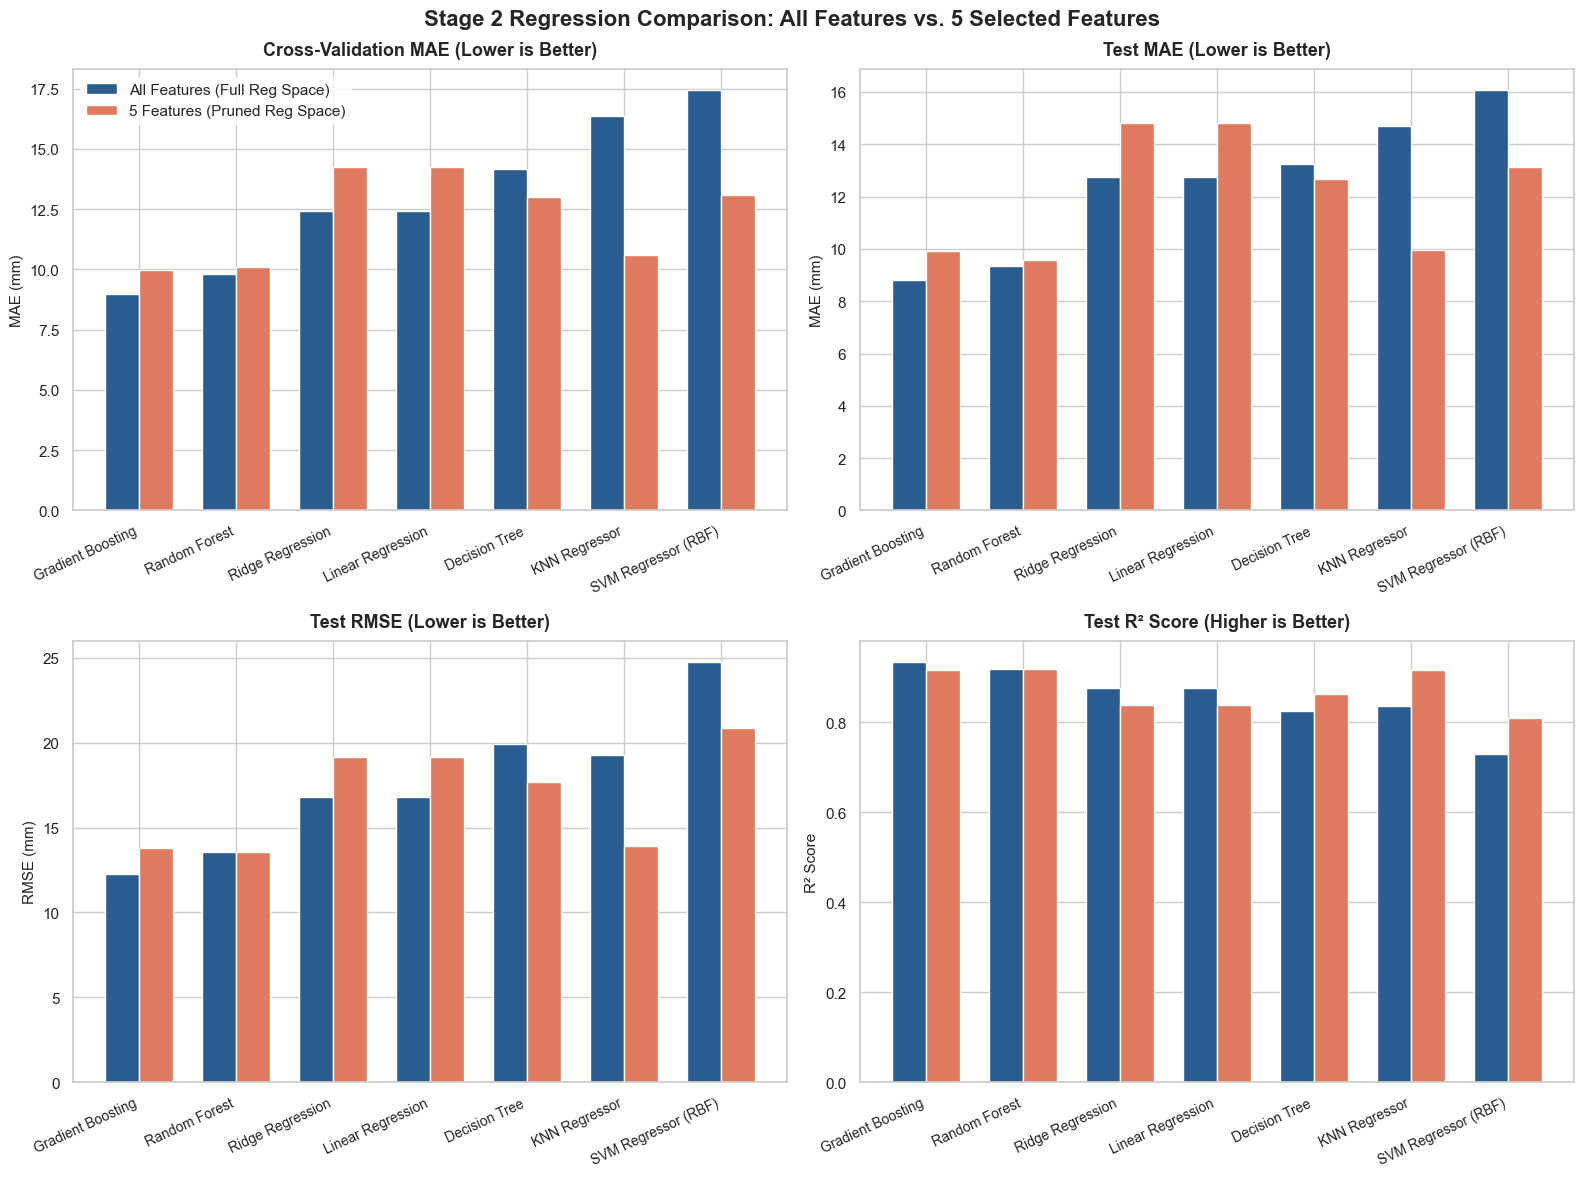

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Prepare numerical data for plotting using your correct Stage 2 variable name
# FIX 1: Point to your Stage 2 full features benchmark table
models = benchmark_table_reg["Model"].values
x = np.arange(len(models))
width = 0.35

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)
axes = axes.flatten()

# Metrics to loop through along with their clean labels and column sources
metrics_config = [
    {"title": "Cross-Validation MAE (Lower is Better)", "ylabel": "MAE (mm)", "sel_col": "CV MAE (Train)", "lim_col": "CV MAE (Train)", "unit": " mm"},
    {"title": "Test MAE (Lower is Better)", "ylabel": "MAE (mm)", "sel_col": "Test MAE (mm)", "lim_col": "Test MAE (mm)", "unit": " mm"},
    {"title": "Test RMSE (Lower is Better)", "ylabel": "RMSE (mm)", "sel_col": "Test RMSE (mm)", "lim_col": "Test RMSE (mm)", "unit": " mm"},
    {"title": "Test R² Score (Higher is Better)", "ylabel": "R² Score", "sel_col": "Test R² Score", "lim_col": "Test R² Score", "unit": None}
]

# 2. Generate the 4 subplots dynamically
for i, config in enumerate(metrics_config):
    ax = axes[i]
    
    # Extract numerical arrays from both tables safely matching the exact model order
    # FIX 2: Point directly to your active Stage 2 regression results tables
    df_sel_idx = benchmark_table_reg.set_index("Model")
    df_lim_idx = benchmark_table_limited_reg.set_index("Model")
    
    if config["unit"]:
        vals_all = df_sel_idx.loc[models, config["sel_col"]].str.replace(config["unit"], "", regex=False).astype(float).values
        vals_5ft = df_lim_idx.loc[models, config["lim_col"]].str.replace(config["unit"], "", regex=False).astype(float).values
    else:
        vals_all = df_sel_idx.loc[models, config["sel_col"]].astype(float).values
        vals_5ft = df_lim_idx.loc[models, config["lim_col"]].astype(float).values

    # Plot bars side-by-side
    rects1 = ax.bar(x - width/2, vals_all, width, label='All Features (Full Reg Space)', color='#2b5c8f')
    rects2 = ax.bar(x + width/2, vals_5ft, width, label='5 Features (Pruned Reg Space)', color='#e07a5f')
    
    # Subplot details
    ax.set_title(config["title"], fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(config["ylabel"], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    
    # Add legend only to the first plot to avoid cluttering the visual space
    if i == 0:
        ax.legend(frameon=True, facecolor='white', edgecolor='none')

# Adjust layout to make room for titles and rotated text labels
plt.suptitle("Stage 2 Regression Comparison: All Features vs. 5 Selected Features", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Based on the graph, we selected the 5-feature set to train the final model because:
## 1. There is no significant difference in performance between using 20 features and 5 features.
## 2. Utilizing fewer features is computationally cost-effective and creates a simpler, more user-friendly interface."

# Hyperparameter Tuning: Optimizing the Random Forest Model

In [62]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor

# 1. Hyperparameter grid with explicit candidate lists for the regressor
param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2]
}

# 2. Group-aware cross-validation
cv_strategy_reg = GroupKFold(n_splits=5)

# 3. Grid search setup using your chosen Random Forest Regressor engine
grid_search_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_reg,
    cv=cv_strategy_reg,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    refit=True,
    verbose=1
)

# 4. FIX 1: Extract groups corresponding to your isolated Stage 2 training row index
groups_reg = df.loc[X_train_reg_selected.index, 'Field_Cycle_ID']

# 5. FIX 2: Fit with groups using your 5-feature regression matrix and positive target array
grid_search_reg.fit(X_train_reg_selected, y_train_reg, groups=groups_reg)

# Extract your fully optimized Stage 2 champion model
best_rf_model_reg = grid_search_reg.best_estimator_

print("\n--- 🎯 Stage 2 Regression Hyperparameter Tuning Summary ---")
print(f"Best RF Parameters : {grid_search_reg.best_params_}")
print(f"Best CV MAE        : {-grid_search_reg.best_score_:.2f} mm")


Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- 🎯 Stage 2 Regression Hyperparameter Tuning Summary ---
Best RF Parameters : {'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV MAE        : 10.02 mm


# Final Model Evaluation & Diagnostic Plots

🏆 FINAL TUNED STAGE 2 REGRESSION MODEL REPORT (Active Watering Only)
Final Mean Absolute Error (MAE) : 9.64 mm
Final Root Mean Squared Error   : 13.69 mm
Final R² Score (Variance Match) : 0.9172


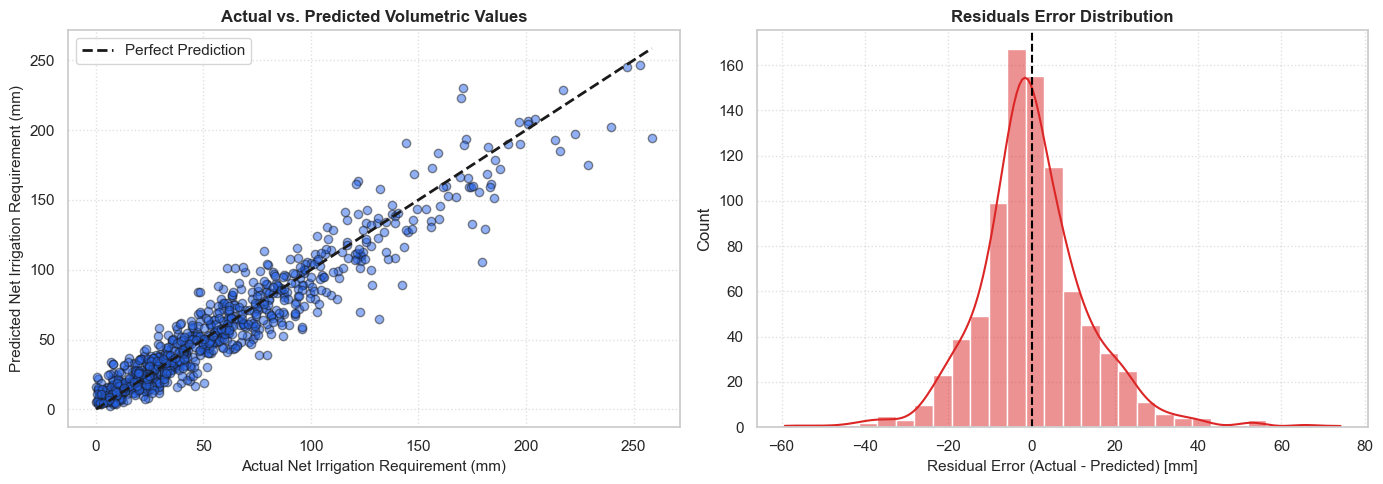

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. FIX 1: Predict on your SELECTED test features using your tuned Stage 2 engine
y_pred_reg = best_rf_model_reg.predict(X_test_reg_selected)

# 2. FIX 2: Calculate Final Performance Metrics against positive test data (y_test_reg)
final_mae_reg  = mean_absolute_error(y_test_reg, y_pred_reg)
final_rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
final_r2_reg   = r2_score(y_test_reg, y_pred_reg)

print("🏆 FINAL TUNED STAGE 2 REGRESSION MODEL REPORT (Active Watering Only)")
print("=" * 65)
print(f"Final Mean Absolute Error (MAE) : {final_mae_reg:.2f} mm")
print(f"Final Root Mean Squared Error   : {final_rmse_reg:.2f} mm")
print(f"Final R² Score (Variance Match) : {final_r2_reg:.4f}")
print("=" * 65)

# 3. Structural Evaluation Graphics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="ticks")

# Plot A: Prediction vs Actuals (Ideally a tight diagonal 45-degree line)
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#2563EB', edgecolors='k')
ideal_line = [min(y_test_reg), max(y_test_reg)]
axes[0].plot(ideal_line, ideal_line, 'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_ylabel('Predicted Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_title('Actual vs. Predicted Volumetric Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot B: Residuals Distribution (Checks if errors are normally distributed around 0)
residuals_reg = y_test_reg - y_pred_reg
sns.histplot(residuals_reg, kde=True, color='#DC2626', ax=axes[1], bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Error (Actual - Predicted) [mm]', fontsize=11)
axes[1].set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Feature Impact Ranking

In [64]:
import pandas as pd

# 1. FIX 1: Extract feature importances from your tuned Stage 2 regressor
importances_reg = best_rf_model_reg.feature_importances_

# 2. FIX 2: Pair scores with your precise 5-feature regression column matrix
irrigation_importance_df = pd.DataFrame({
    'Feature': X_test_reg_selected.columns,
    'Importance Score': importances_reg,
    'Contribution': ['High Impact' if imp > 0.10 else 'Moderate/Low Impact' for imp in importances_reg]
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("🌾 STAGE 2 IRRIGATION FEATURE IMPORTANCE RANKING (Top 5 Pruned)")
print("="*65)
display(irrigation_importance_df)


🌾 STAGE 2 IRRIGATION FEATURE IMPORTANCE RANKING (Top 5 Pruned)


,Feature,Importance Score,Contribution
0,Stage_Duration_days,0.351113,High Impact
1,Rainfall_mm,0.281156,High Impact
2,Reference_ET0_mm_day,0.211011,High Impact
3,Crop_Coefficient_Kc,0.123428,High Impact
4,Tmax_C,0.033292,Moderate/Low Impact


### The input features for the classification model

In [68]:
selected_feats_clf

['Season',
 'Stage_Duration_days',
 'Tmax_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Climate_Zone_Wet']

### The input feature for the regression model

In [70]:
limited_features_reg

['Stage_Duration_days',
 'Rainfall_mm',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc',
 'Tmax_C']

# Combining the both models

In [71]:
import numpy as np
import pandas as pd

# 1. DEFINE YOUR EXPLICIT FEATURE POOLS
# Pointing exactly to your curated column name arrays
selected_feats_clf = [
    'Season', 'Stage_Duration_days', 'Tmax_C', 'Humidity_pct', 
    'Rainfall_mm', 'Sunlight_Hours', 'Reference_ET0_mm_day', 
    'Crop_Coefficient_Kc', 'Climate_Zone_Wet'
]

limited_features_reg = [
    'Stage_Duration_days', 'Rainfall_mm', 'Reference_ET0_mm_day', 
    'Crop_Coefficient_Kc', 'Tmax_C'
]

def predict_hurdle_pipeline(X_input_raw):
    """
    Unified production inference engine for Sri Lanka Irrigation.
    Executes a clean, leak-free, two-stage Hurdle framework with perfect feature alignment.
    """
    # Create an array of zeros to hold the final output predictions
    final_predictions = np.zeros(len(X_input_raw))
    
    # -----------------------------------------------------------------
    # STAGE 1: THE CLASSIFICATION HURDLE (Gatekeeper Valve)
    # -----------------------------------------------------------------
    # 1. Scale ALL encoded input features using your Stage 1 scaler
    X_all_scaled_clf = pd.DataFrame(
        scaler.transform(X_input_raw), 
        columns=X_input_raw.columns, 
        index=X_input_raw.index
    )
    
    # FIX: Isolate the EXACT 9 features your Classifier was trained on
    X_clf_input = X_all_scaled_clf[selected_feats_clf]
    
    # 2. Predict the continuous probability of needing water
    probabilities = best_rf_classifier.predict_proba(X_clf_input)[:, 1]
    
    # 3. 0.50 threshold to check who clears the hurdle
    cleared_hurdle_mask = probabilities >= 0.50
    
    # If no records clear the hurdle, shut down early and return all zeros
    if not np.any(cleared_hurdle_mask):
        return final_predictions
        
    # -----------------------------------------------------------------
    # STAGE 2: THE CONTINUOUS REGRESSION (Volume Dial)
    # -----------------------------------------------------------------
    # Isolate only the rows that cleared the classification hurdle
    X_reg_raw = X_input_raw[cleared_hurdle_mask]
    
    # 1. Scale features using the Stage 2 Regressor Scaler
    X_all_scaled_reg = pd.DataFrame(
        reg_scaler.transform(X_reg_raw), 
        columns=X_reg_raw.columns, 
        index=X_reg_raw.index
    )
    
    # FIX: Isolate the EXACT 5 features your Regressor was trained on
    X_reg_input = X_all_scaled_reg[limited_features_reg]
    
    # 2. Predict the exact water volume (mm) for the rows that passed the hurdle
    predicted_volumes = best_rf_model_reg.predict(X_reg_input)
    
    # 3. Map the continuous volumes back into the final prediction array
    final_predictions[cleared_hurdle_mask] = predicted_volumes
    
    return final_predictions

# =====================================================================
# RUN THE INTEGRATED EVALUATION ON YOUR UNSEEN TEST DATA
# =====================================================================
# Pass your raw, full test features through the completed Hurdle system
y_final_pred = predict_hurdle_pipeline(X_test_encoded)
print("✅ Success! Pipeline executed cleanly across both stages.")

✅ Success! Pipeline executed cleanly across both stages.


In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Score the entire integrated Hurdle Model against original raw y_test (including its zeros!)
integrated_mae  = mean_absolute_error(y_test, y_final_pred)
integrated_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
integrated_r2   = r2_score(y_test, y_final_pred)

print("\n🏆 FINAL INTEGRATED TWO-STAGE HURDLE MODEL REPORT")
print("=" * 65)
print(f"Hurdle Pipeline Final MAE   : {integrated_mae:.2f} mm")
print(f"Hurdle Pipeline Final RMSE  : {integrated_rmse:.2f} mm")
print(f"Hurdle Pipeline Final R²    : {integrated_r2:.4f}")
print("=" * 65)


🏆 FINAL INTEGRATED TWO-STAGE HURDLE MODEL REPORT
Hurdle Pipeline Final MAE   : 4.38 mm
Hurdle Pipeline Final RMSE  : 9.23 mm
Hurdle Pipeline Final R²    : 0.9503
